# Local에서 실행하기 위한 code
### Colab을 사용하는 경우를 위해 local에서 쉽게 파일을 압축하고 google drive에 보내기 위한 코드
- map_generator.py, environment.py가 잘 작동하는지 확인
- Source code 파일과 훈련을 재개할 model을 압축하여 google drive에 보내는 코드가 작성되어 있음
- Tensorboard server를 열거나 google drive를 wsl과 mount하는 명령어가 적혀있음 -> 이를 Terminal에 적어서 실행

### Python 파일을 검사하기 위한 사전 설정

In [1]:
# Working directory 수정: 압축할 lg_robot 폴더의 위치
# %cd c:\Users\wrlat\Desktop\LCH\LG_robot_DQN
%cd /home/wrl/LG_robot_DQN

/home/wrl/LG_robot_DQN


In [2]:
# Python 파일 수정 시 자동으로 새로고침
%load_ext autoreload
%autoreload 2

## Python 파일들이 잘 수행되는지 검사

### map_generator.py

In [ ]:
from path_planner.map_generator import generate_map_by_seed_and_visualize
from path_planner.config import EnvConfig

generate_map_by_seed_and_visualize(robot_diameter=EnvConfig().robot_size, seed=128, level=4)

In [ ]:
from path_planner.utils.visualizer import visualize_saved_map, visualize_mode_map
from path_planner.config import MAP_SAVE_DIR
from path_planner.map_generator import ObstacleMap
import os

map_file_path = os.path.join(MAP_SAVE_DIR, "test", "test_map_3m3m_level3_07.npy")
visualize_saved_map(map_file_path)
visualize_mode_map(map_file_path)
 
obs_map = ObstacleMap.load_from_file(map_file_path)

### environment.py

In [ ]:
%cd /home/wrl/LG_robot_DQN
%load_ext autoreload
%autoreload 2

from path_planner.config import EnvConfig, DEFAULT_SEED
from path_planner.environment import get_args, CoverageEnv
from path_planner.utils.map_utils import make_robot_mask
from path_planner.utils.visualizer import visualize_mask
from path_planner.map_layer import MapConfigSchema
import sys

sys.argv = [" ", # 파일명이 없으므로 sys.argv[0]은 공백으로 처리
            # "--robot",
            "--see_map",
            "--see_obs",
            "--debug_reset",
            "--debug_step"]
args = get_args()
cfg = EnvConfig()
env = CoverageEnv(cfg=cfg)

# 0. Robot visualize
if args.robot:
    visualize_mask(make_robot_mask(robot_size=cfg.robot_size))

map_config = MapConfigSchema(level=1, H=None, W=None)
obs, info = env.reset(map_config=map_config)
if args.debug_reset:
    if args.see_map:
        # 1. Map visualize: Agent layer, Cleaned layer, Obstacle layer, Collision map, 
        env.show_visualized_img('layer')
        env.show_visualized_img('traj')
    if args.see_obs:
        # 2. observation visualization
        env.show_visualized_img('obs')

if args.debug_step:
    # 3. step() method
    # action_seq = [0]*150 + [1]*3 + [3]*150 + [2]*250 + [3]*100 + [1]*200
    pattern = [0]*30 + [13] + [0]*10 + [13] + [0]*30 + [14] + [0]*10 + [14]
    action_seq = pattern * 20
    for action in action_seq:
        obs, reward, terminated, truncated, info = env.step(action)
    if args.see_map:
        # 1. Map visualize: Agent layer, Cleaned layer, Obstacle layer, Collision map, 
        env.show_visualized_img('layer')
        env.show_visualized_img('traj')
    if args.see_obs:
        # 2. observation visualization
        env.show_visualized_img('obs')

### Local에서 파일 실행

In [ ]:
%cd ~/LG_robot_DQN

from path_planner.main import main
import sys

args_str = """
    --mode train
    --model_name LSTM_model_detach_20_add_frontier.pth
    --optimizer adam
    --batch_size 32
    --lr 3e-4
    --momentum 0.9
    --valid_freq 1
    --ckp_freq 1
    --valid_map_num 5
    --valid_start_point_num 1
    --use_train_maps
    --use_wandb
"""

sys.argv = [" "] + args_str.split()

# Training
main()

/home/wrl/LG_robot_DQN
------------------------------
  [System Configuration]
  > Device: CUDA
  > GPU Name: NVIDIA GeForce RTX 4070 Ti SUPER
  > VRAM: 17.17 GB
------------------------------
Checking if test maps are exist...
  There are 1000 map files for testing.
Test model loaded: src/path_planner/path_planner/models/LSTM_model_detach_20_add_frontier.pth
Use 250 maps per level for test.


Level 4 Maps:  80%|████████  | 200/250 [20:36<05:08,  6.18s/it]

Can't reset map file: test_map_L4_0200.npy


Level 4 Maps:  82%|████████▏ | 205/250 [20:59<04:00,  5.33s/it]

Can't reset map file: test_map_L4_0205.npy


Level 4 Maps:  88%|████████▊ | 220/250 [22:22<02:40,  5.33s/it]

Can't reset map file: test_map_L4_0220.npy


Level 4 Maps: 100%|██████████| 250/250 [25:05<00:00,  6.02s/it]


[Final Coverage Summary by Level]
 ▶ Level 1 (Total tests: 250)
    - Final Coverage(%): 92.37 ± 5.70%
 ▶ Level 2 (Total tests: 250)
    - Final Coverage(%): 89.77 ± 11.49%
 ▶ Level 3 (Total tests: 250)
    - Final Coverage(%): 88.06 ± 11.42%
 ▶ Level 4 (Total tests: 247)
    - Final Coverage(%): 84.91 ± 15.55%

[2. Detailed Results by Target Coverage]

 Target Coverage: 85.0%
------------------------------------------------------------
   Level 1 | Success Rate:  88.8% (222/250) | Overlap: 20.49 ± 7.42% | Time:  1.51 ± 0.34m
   Level 2 | Success Rate:  82.8% (207/250) | Overlap: 21.49 ± 6.66% | Time:  1.75 ± 0.39m
   Level 3 | Success Rate:  76.4% (191/250) | Overlap: 23.45 ± 7.10% | Time:  2.18 ± 0.42m
   Level 4 | Success Rate:  68.4% (169/247) | Overlap: 26.06 ± 7.57% | Time:  2.52 ± 0.54m
------------------------------------------------------------
   [Overall for Target 85.0%]
   - Success Rate : 79.14% (789/997)
   - Overlap Rate : 22.66 ± 7.48%
   - Cleaning Time: 1.95 ± 0.57 

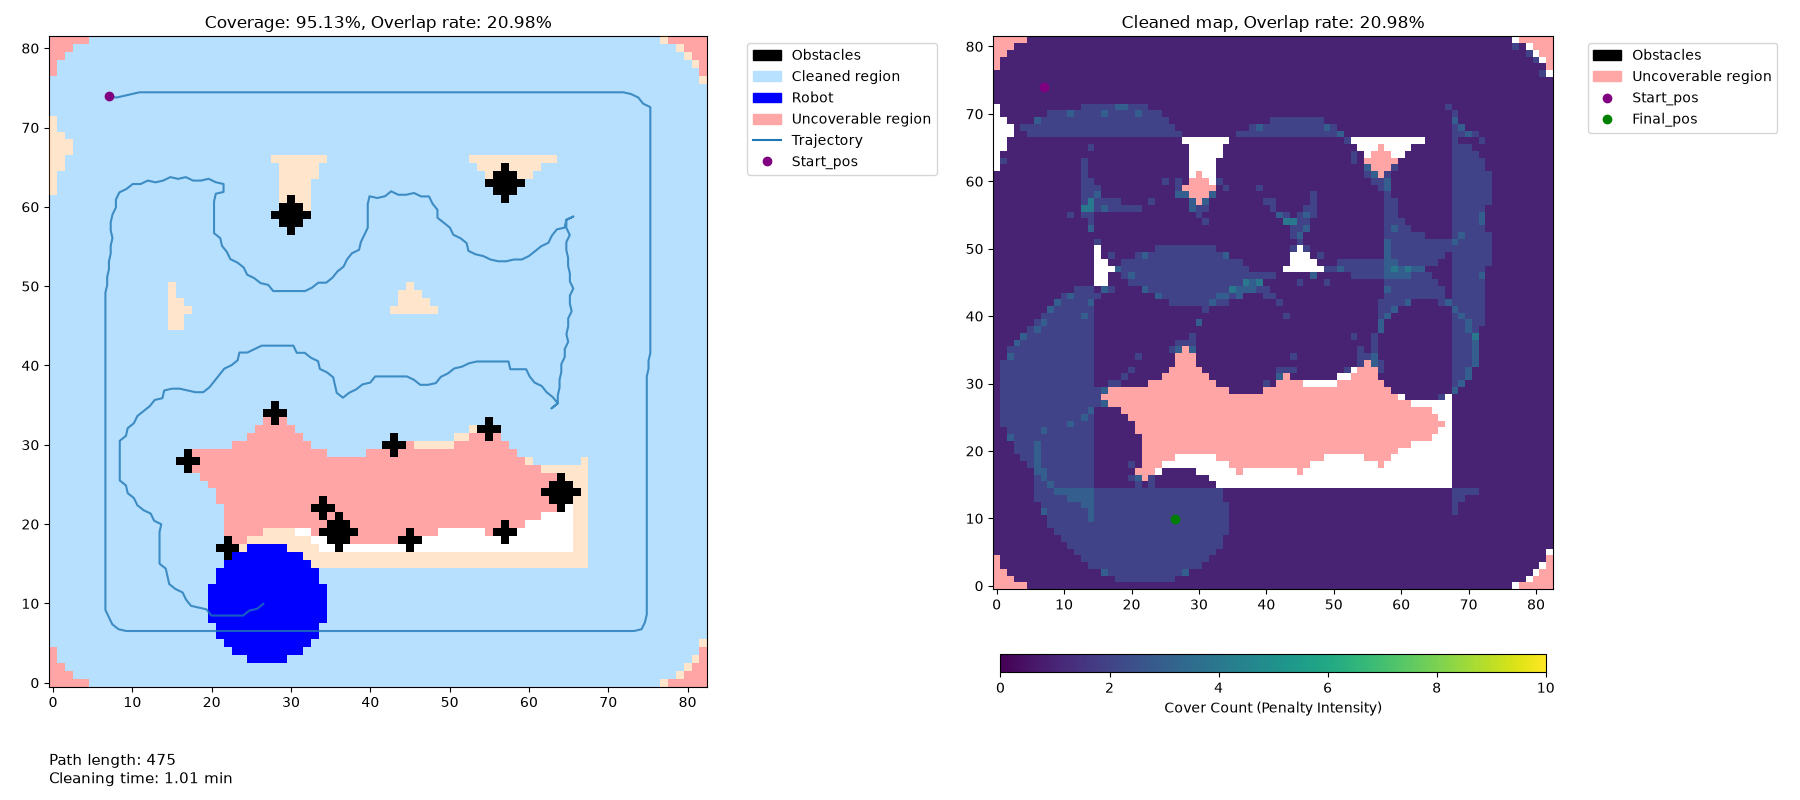

    #2 - Map name: test_map_L1_0011.npy | Final Cov: 95.1%, Overlap: 15.1%, Time: 1.3m


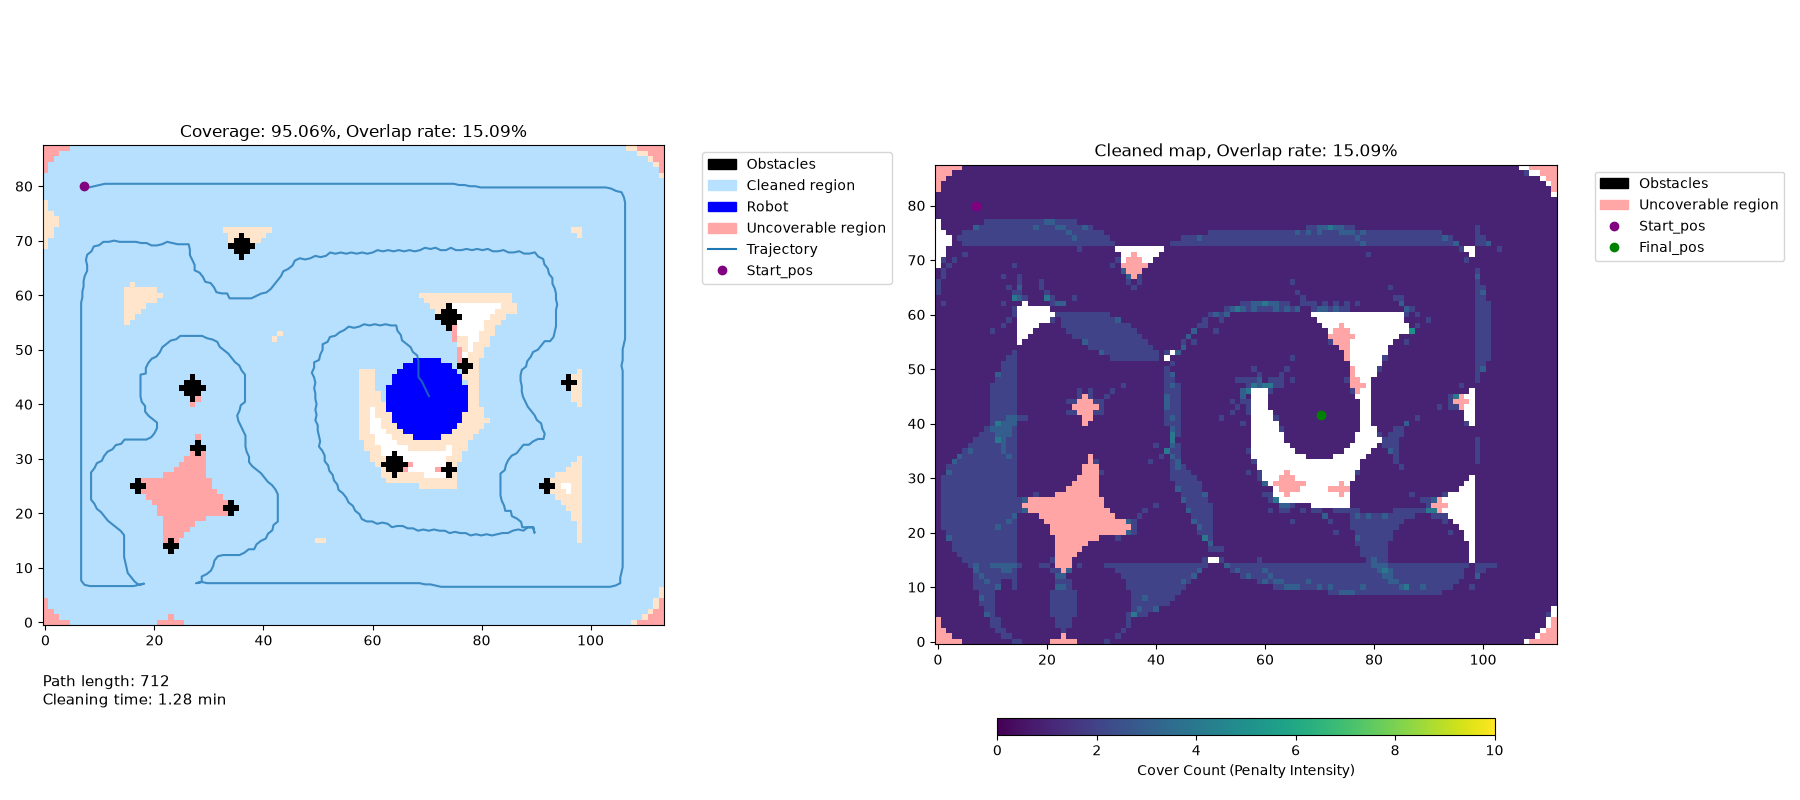

    #3 - Map name: test_map_L1_0167.npy | Final Cov: 95.1%, Overlap: 14.1%, Time: 1.3m


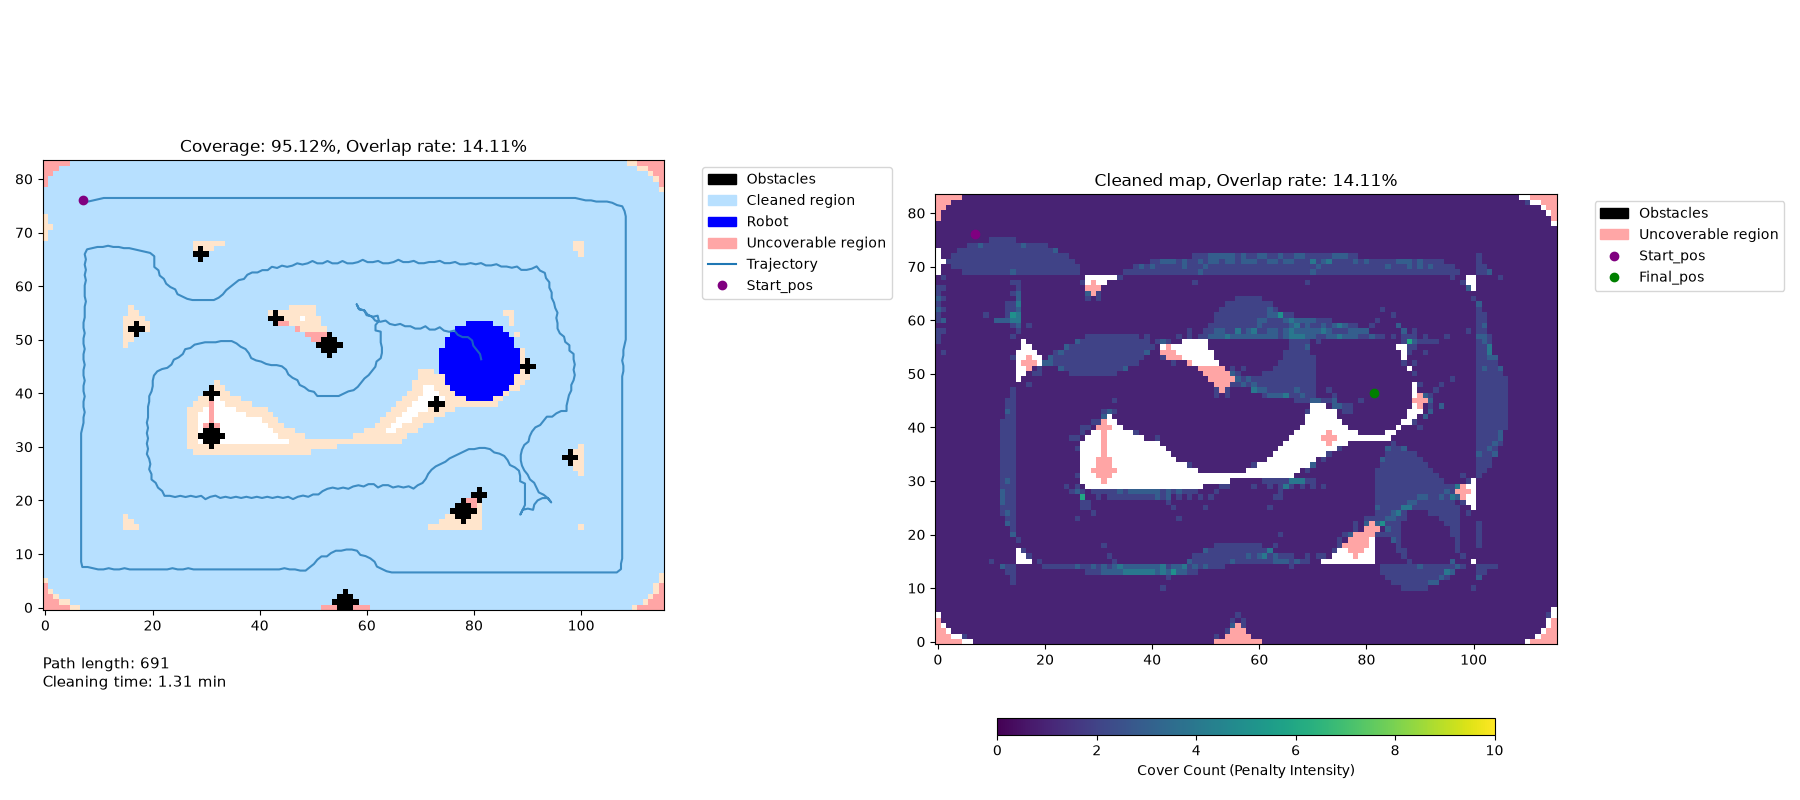


  [Median Paths] (Top 3)
    #1 - Map name: test_map_L1_0037.npy | Final Cov: 95.0%, Overlap: 44.1%, Time: 1.6m


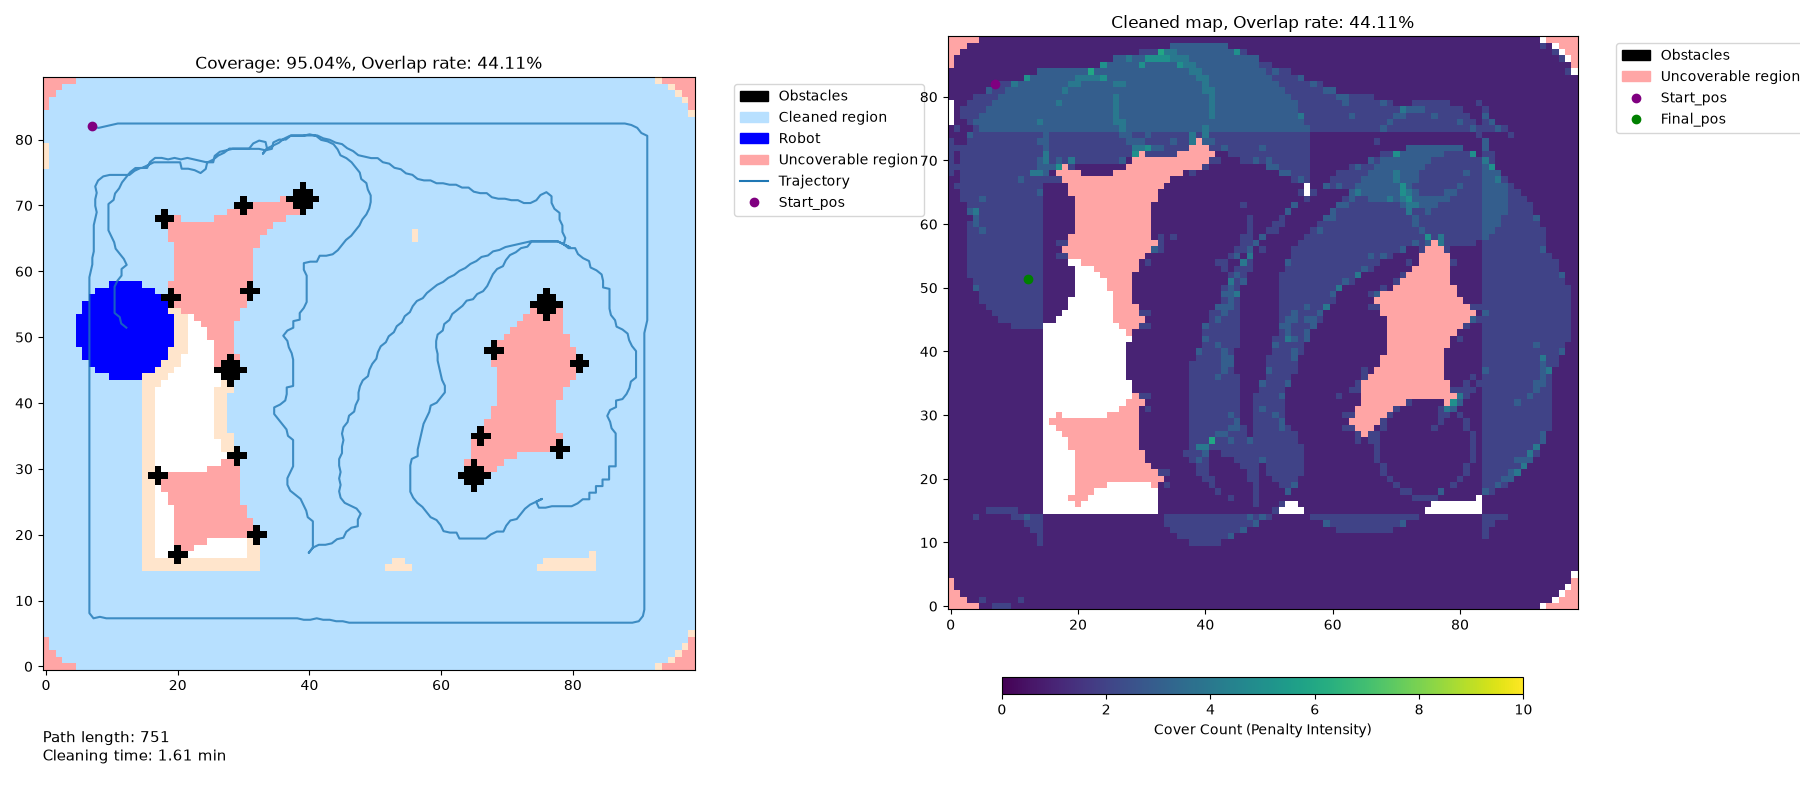

    #2 - Map name: test_map_L1_0047.npy | Final Cov: 95.0%, Overlap: 36.8%, Time: 2.0m


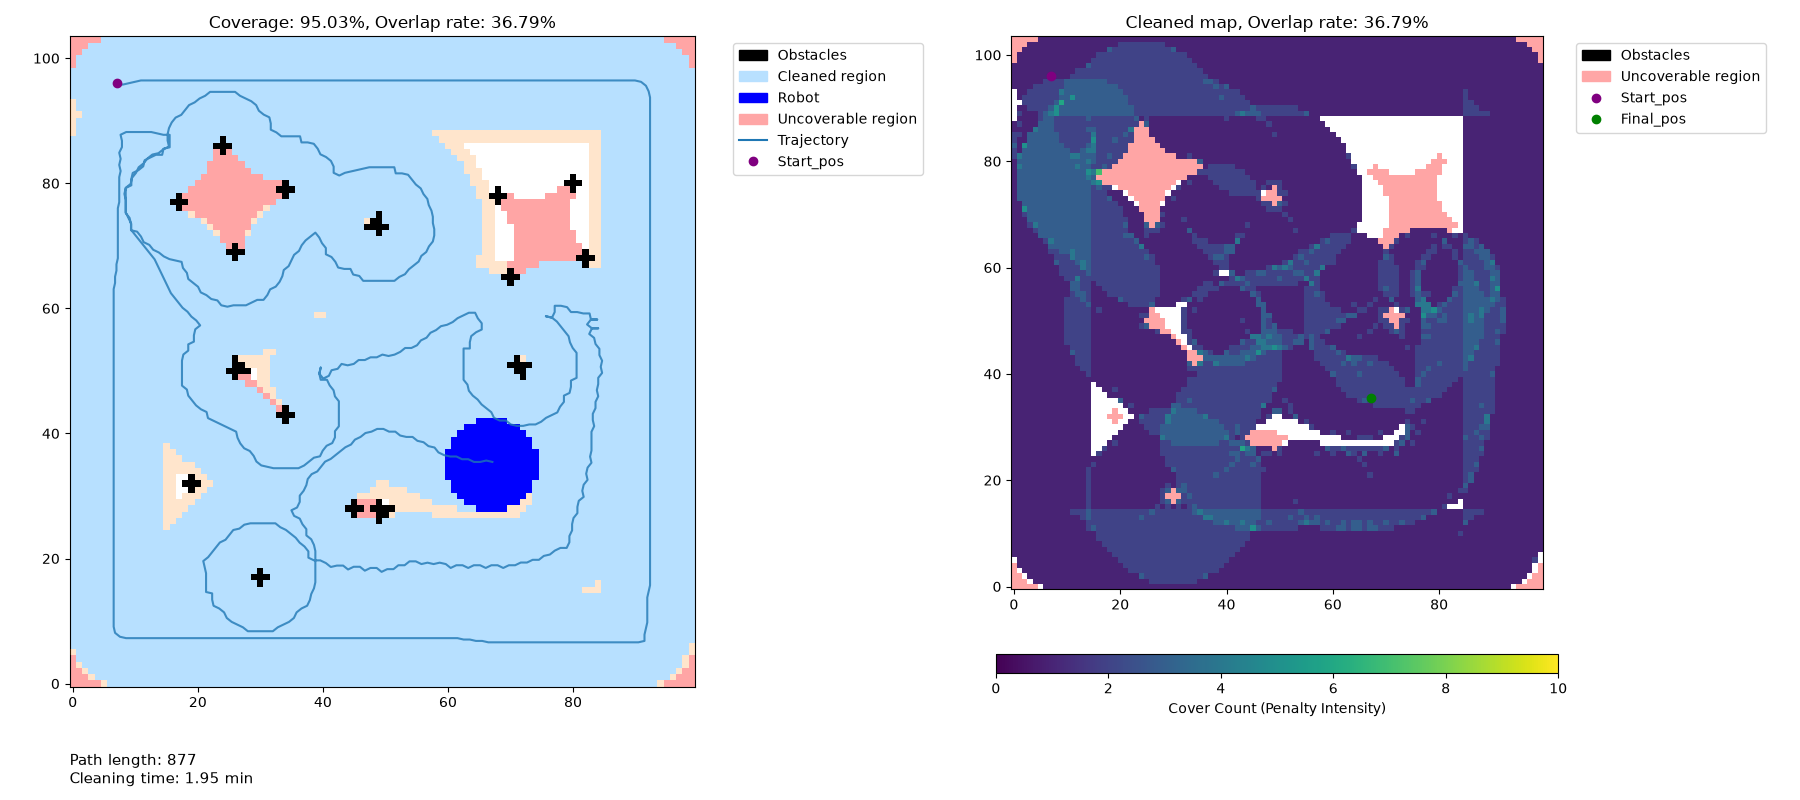

    #3 - Map name: test_map_L1_0038.npy | Final Cov: 95.0%, Overlap: 40.1%, Time: 2.1m


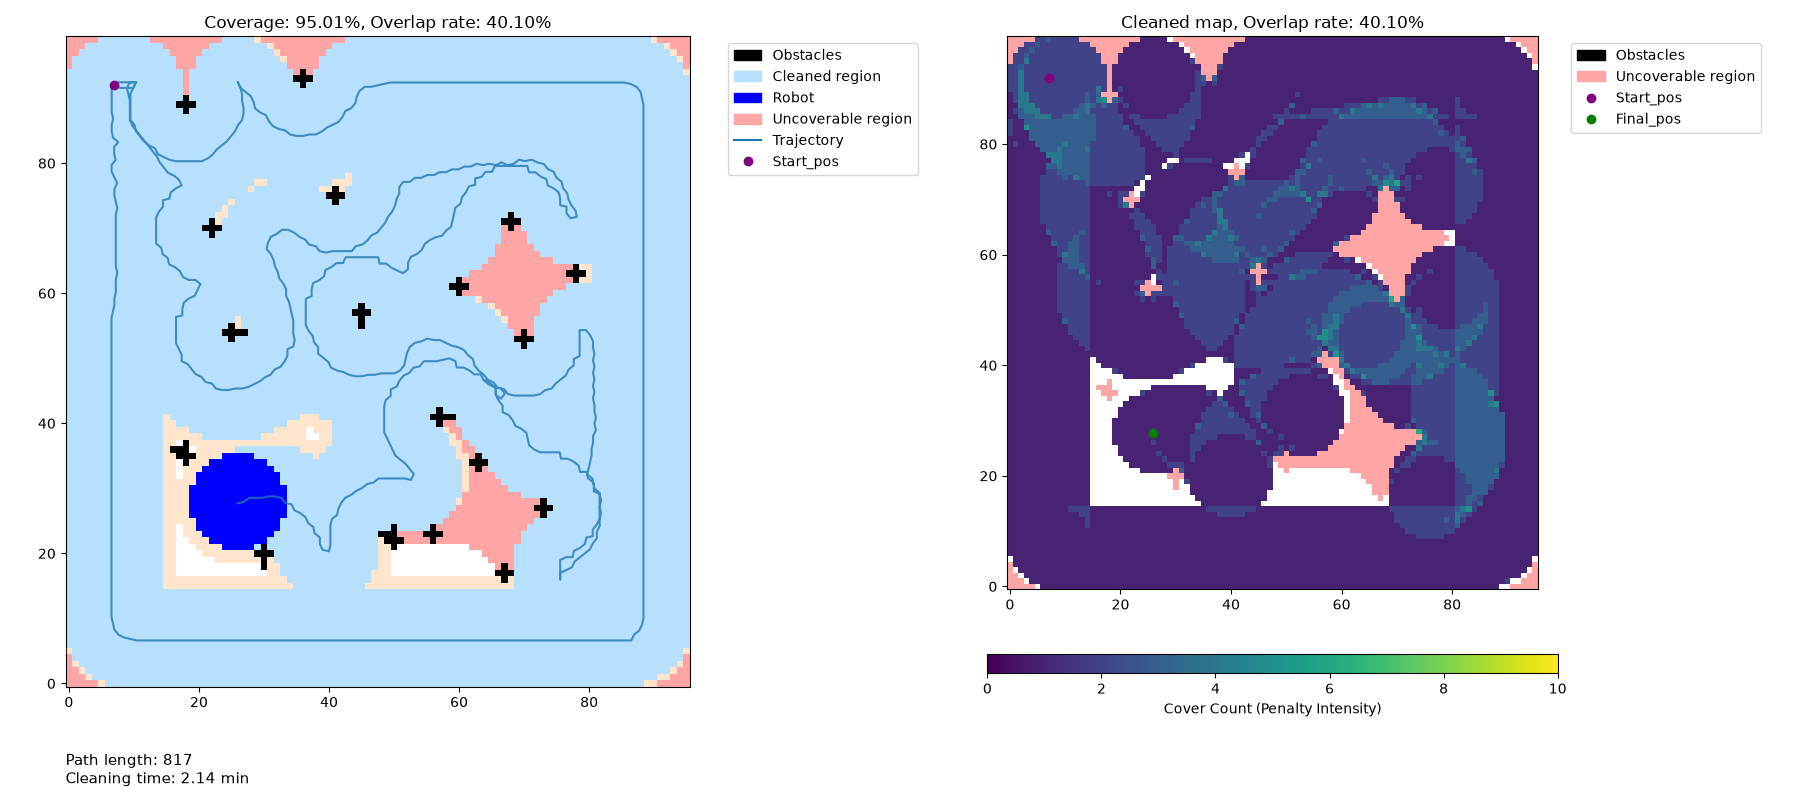


  [Worst Paths] (Top 3)
    #1 - Map name: test_map_L1_0216.npy | Final Cov: 59.7%, Overlap: 20.0%, Time: 0.9m


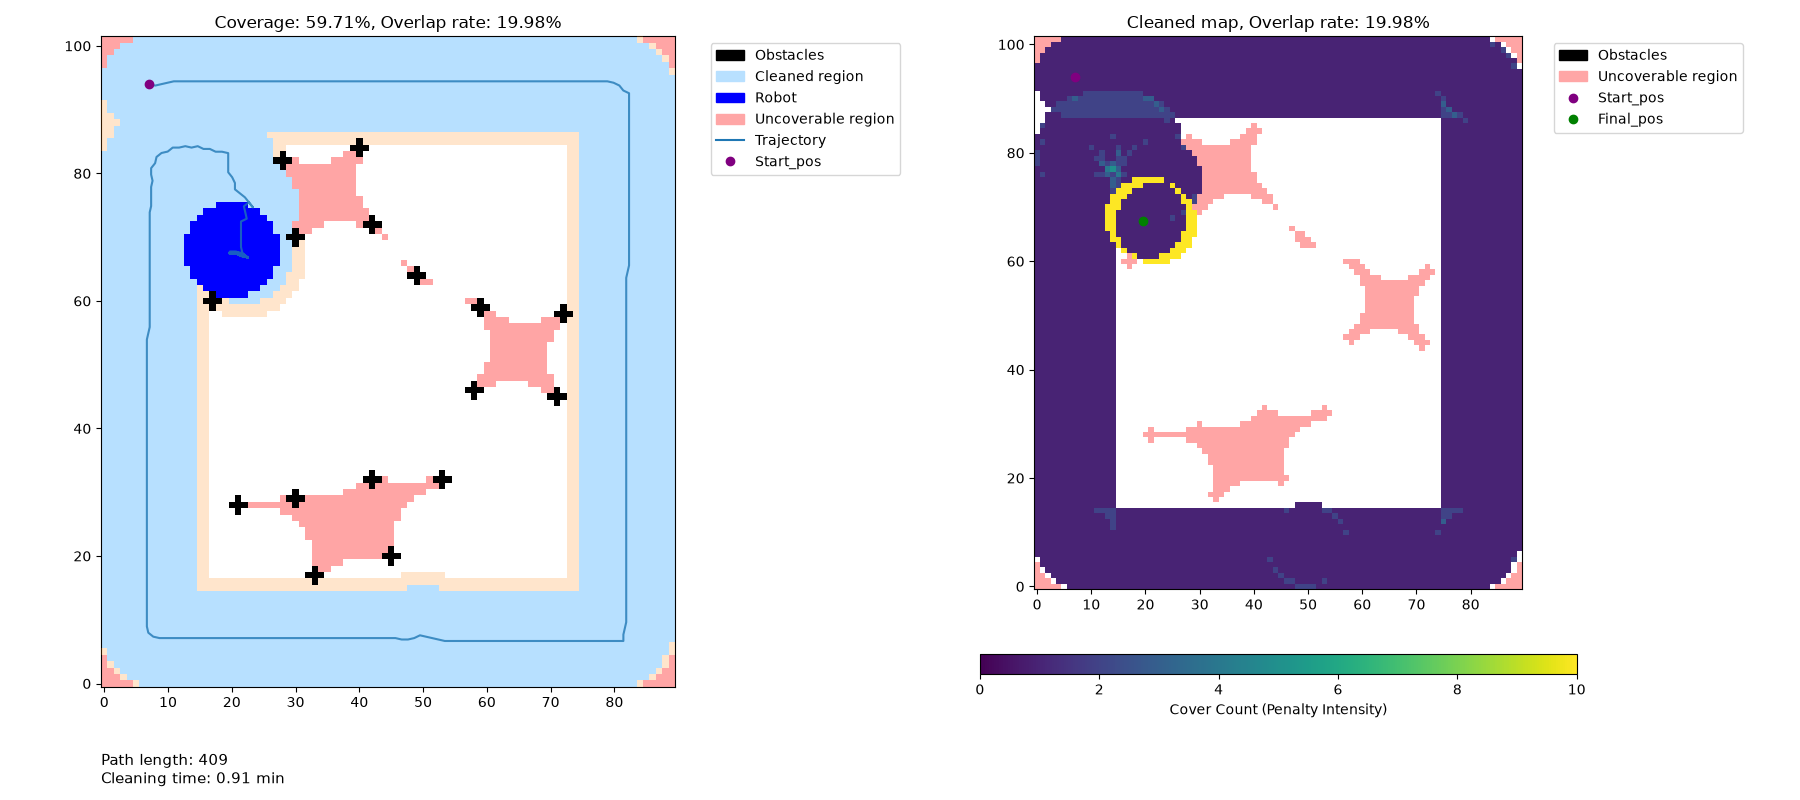

    #2 - Map name: test_map_L1_0155.npy | Final Cov: 61.9%, Overlap: 23.7%, Time: 1.9m


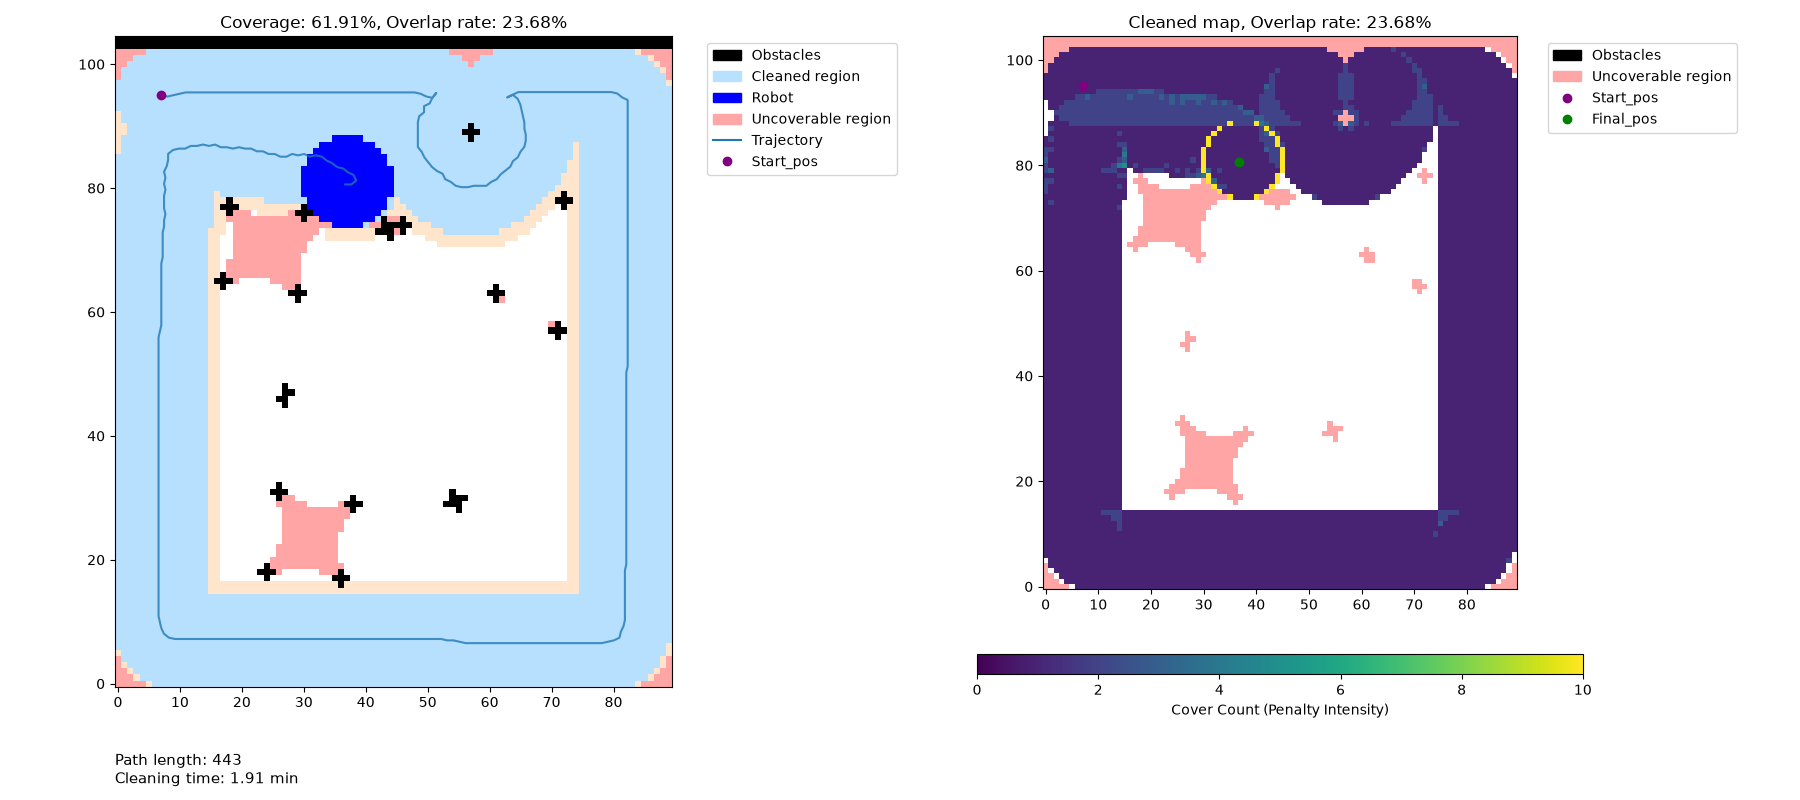

    #3 - Map name: test_map_L1_0192.npy | Final Cov: 69.4%, Overlap: 28.5%, Time: 1.3m


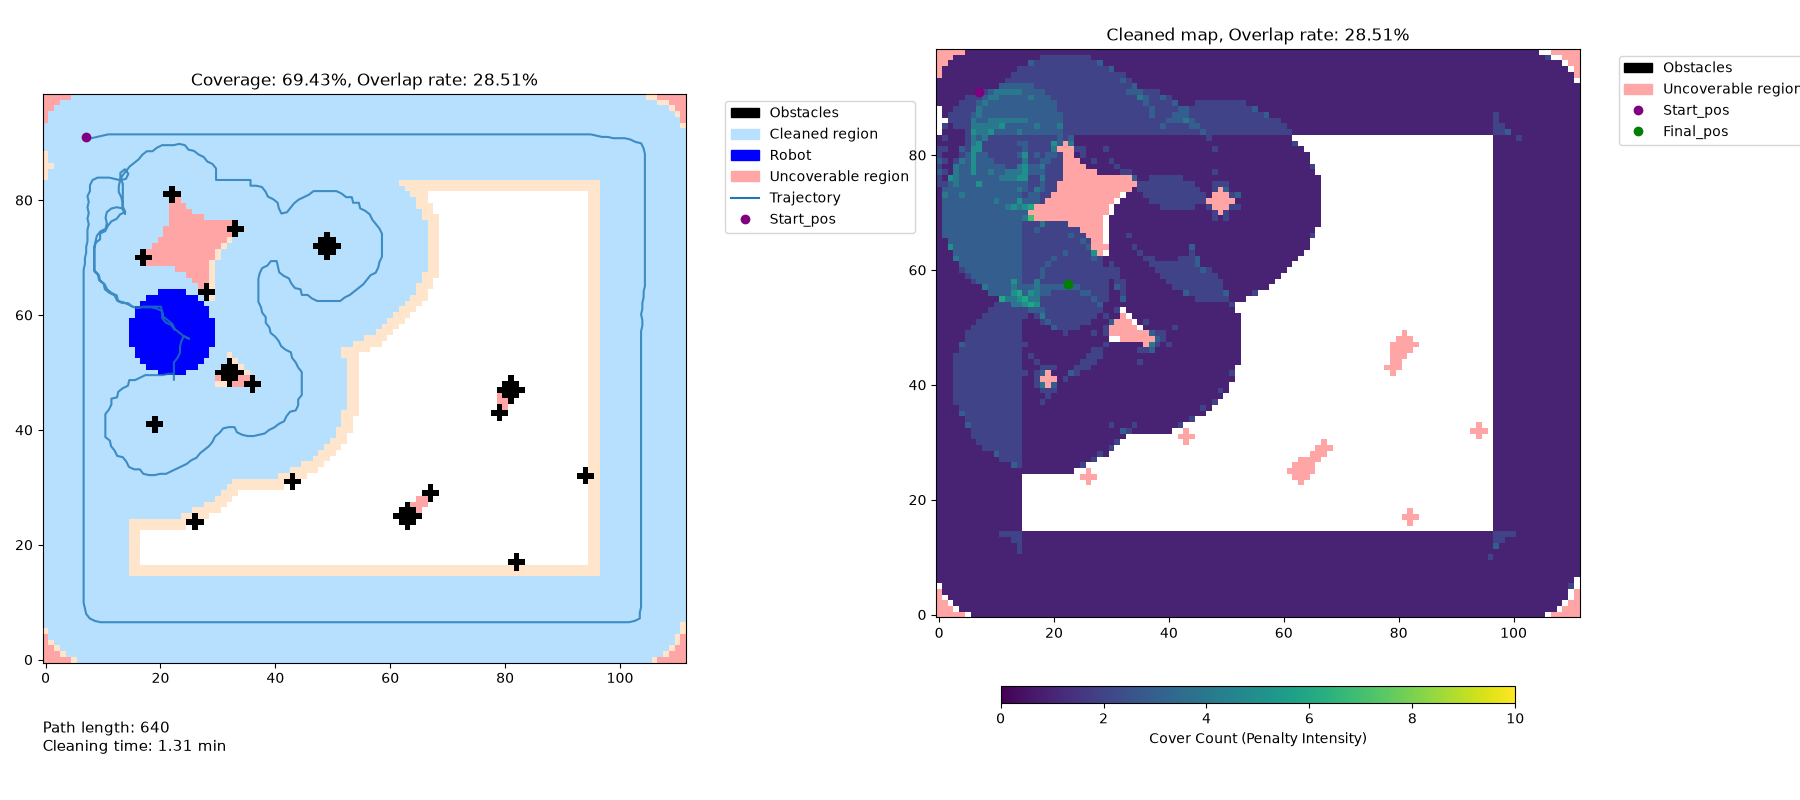


 Visualization for Map Condition Level 2

  [Best Paths] (Top 3)
    #1 - Map name: test_map_L2_0176.npy | Final Cov: 95.1%, Overlap: 21.3%, Time: 1.0m


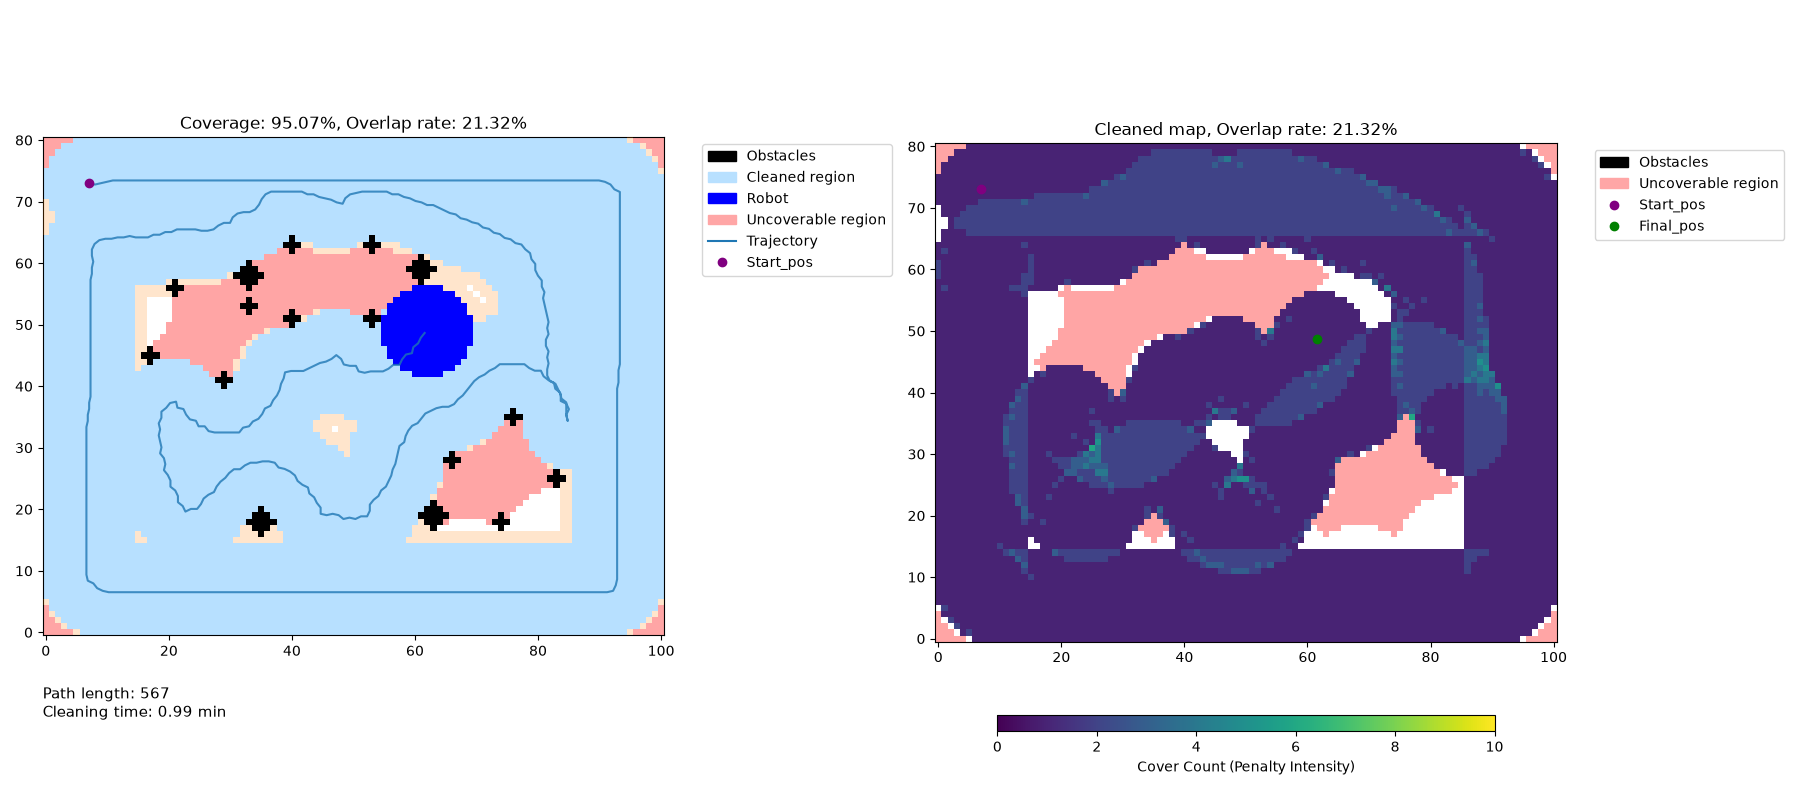

    #2 - Map name: test_map_L2_0194.npy | Final Cov: 95.1%, Overlap: 26.2%, Time: 1.2m


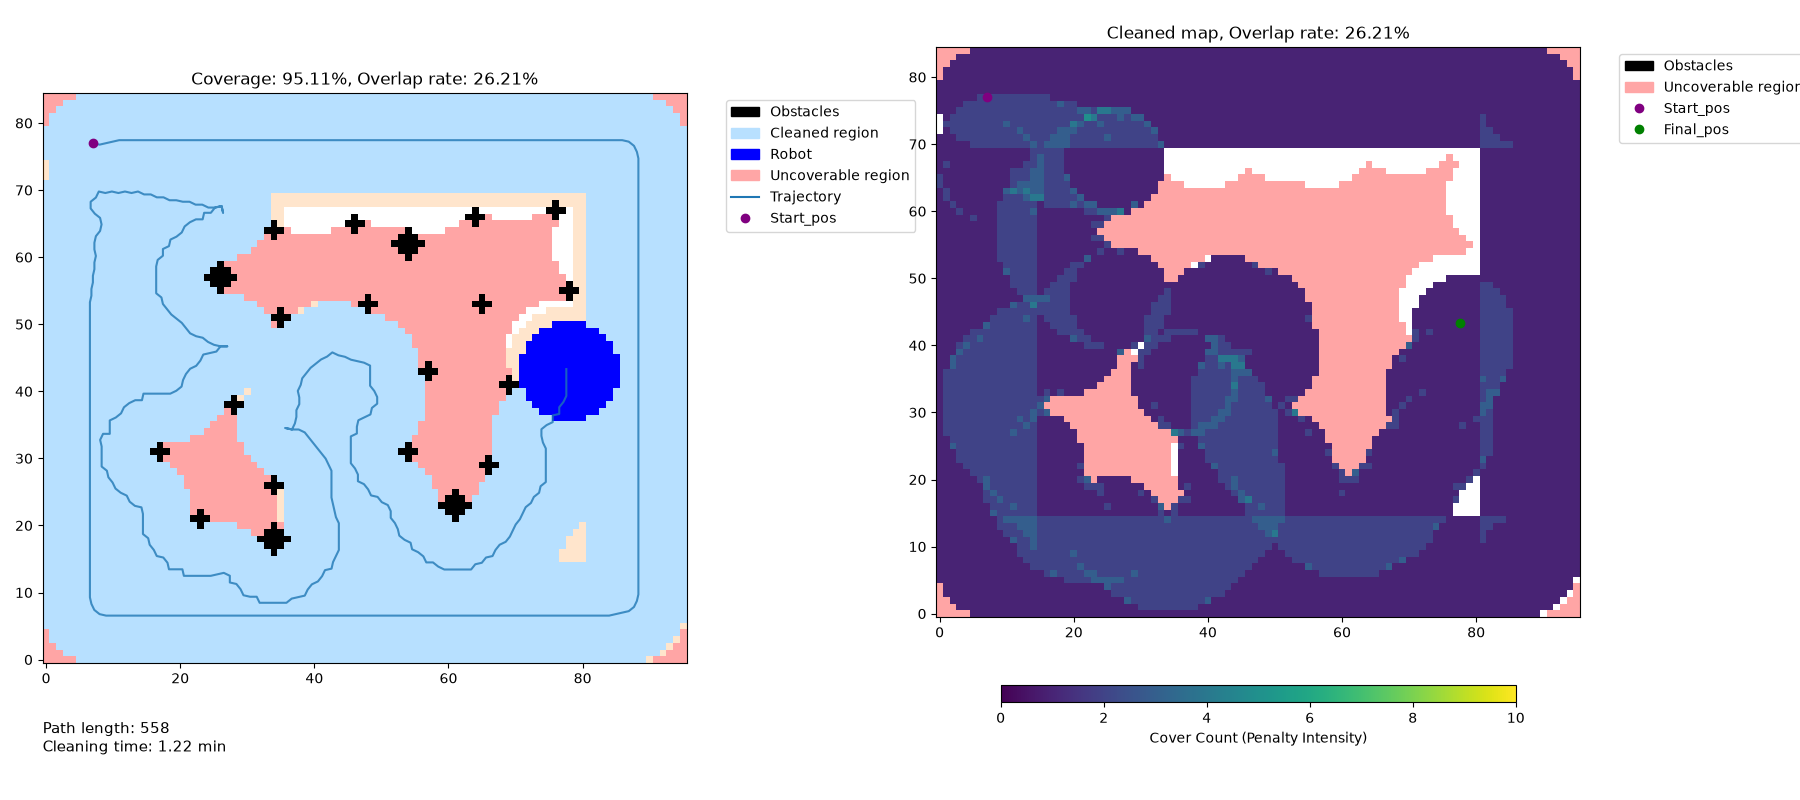

    #3 - Map name: test_map_L2_0231.npy | Final Cov: 95.1%, Overlap: 21.5%, Time: 1.5m


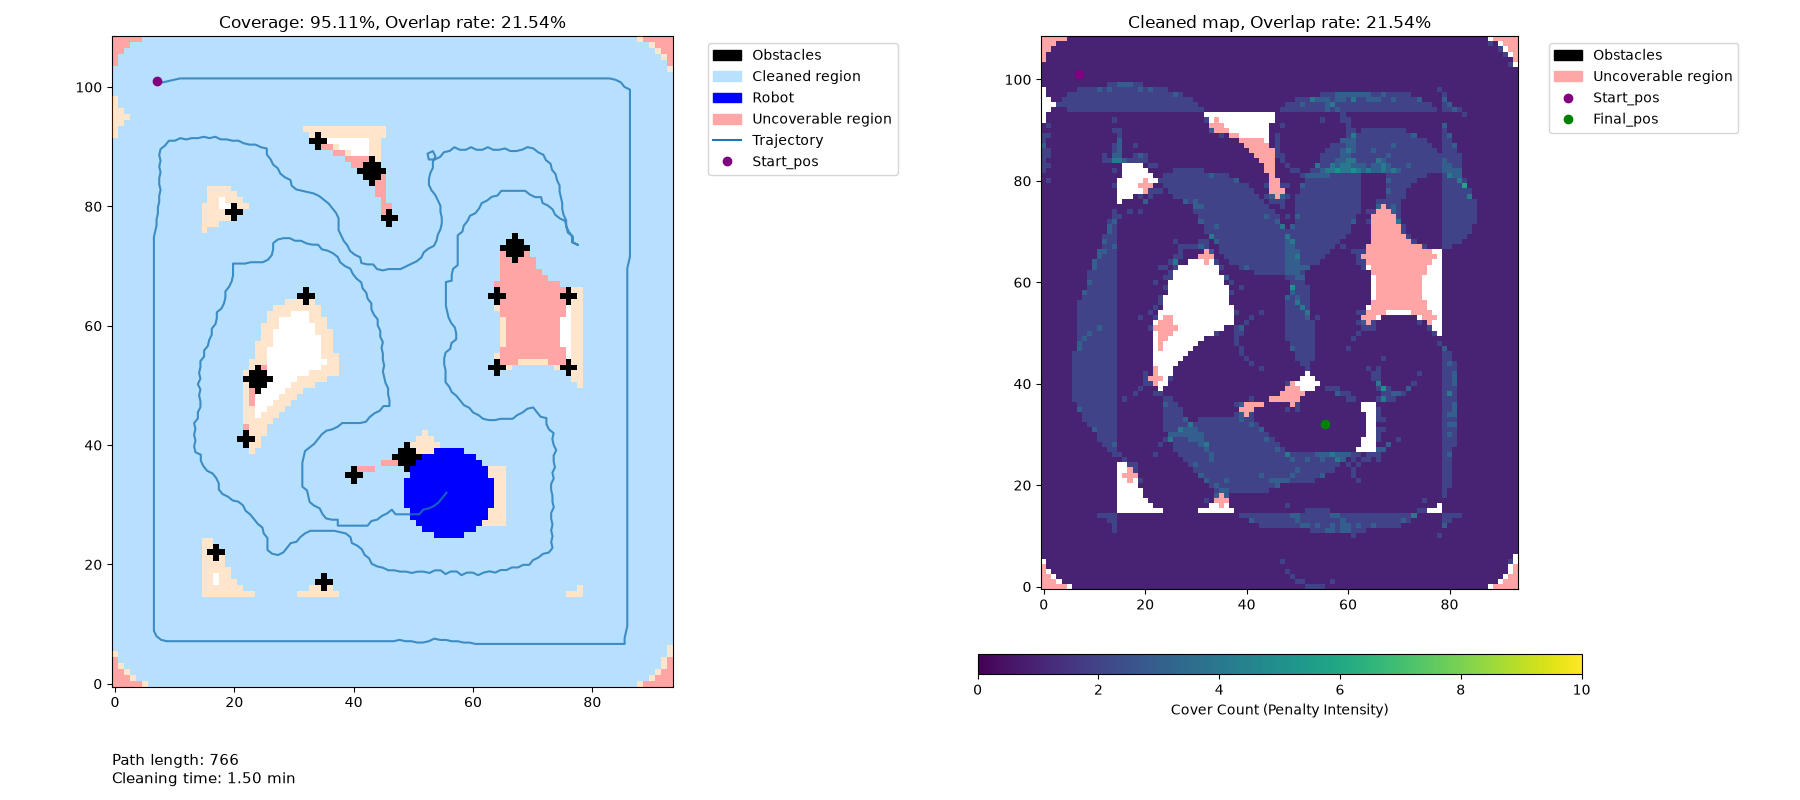


  [Median Paths] (Top 3)
    #1 - Map name: test_map_L2_0129.npy | Final Cov: 95.0%, Overlap: 28.5%, Time: 2.9m


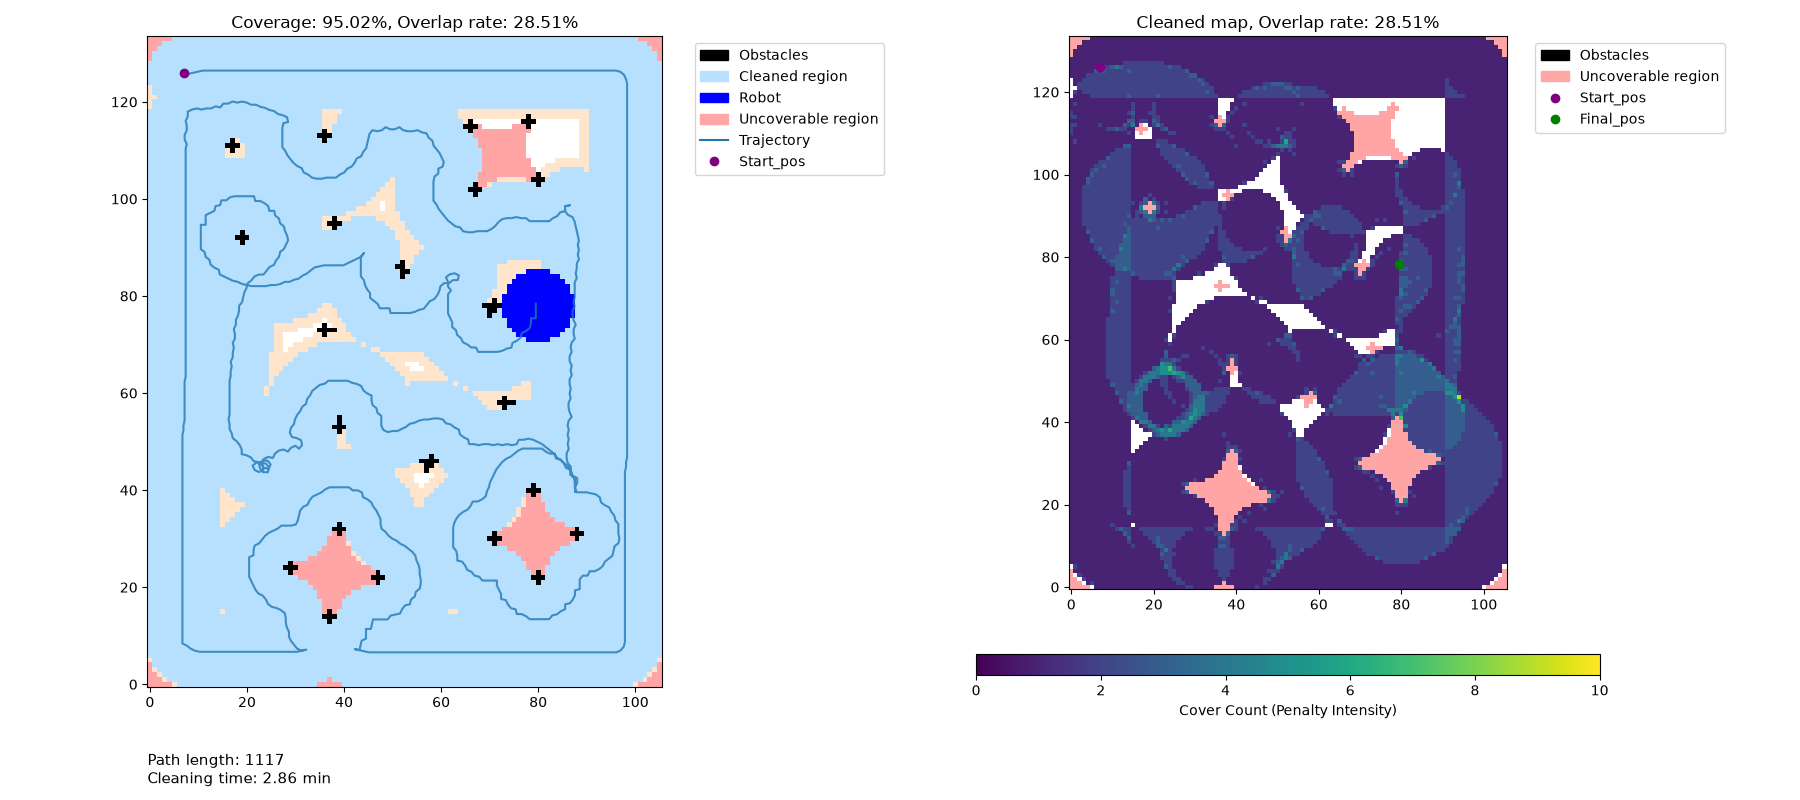

    #2 - Map name: test_map_L2_0205.npy | Final Cov: 95.1%, Overlap: 33.9%, Time: 3.2m


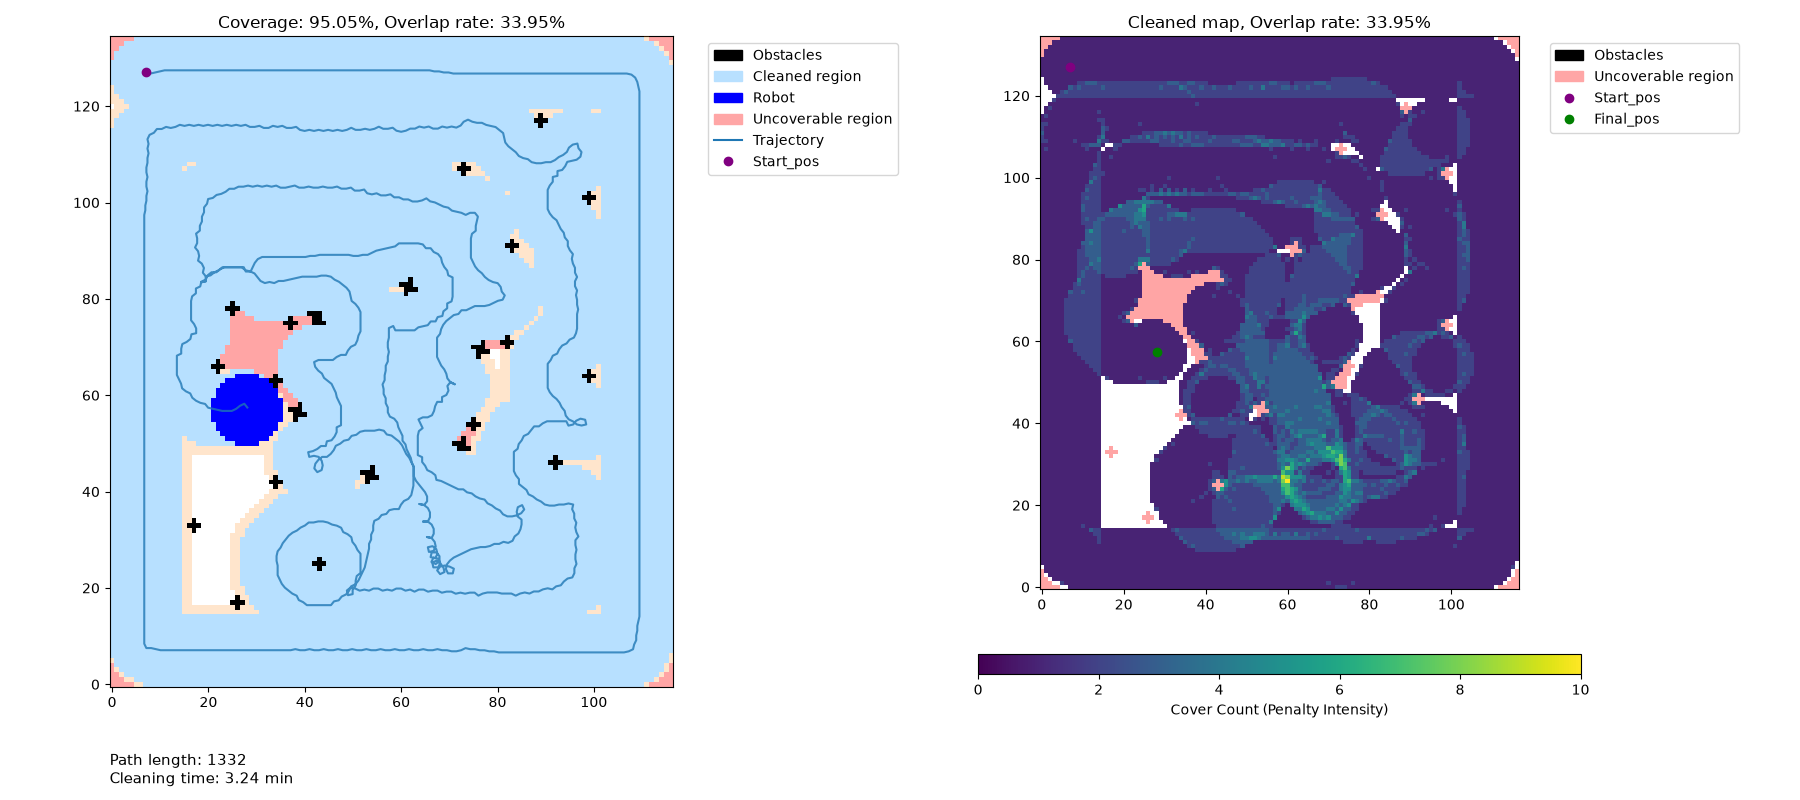

    #3 - Map name: test_map_L2_0193.npy | Final Cov: 93.3%, Overlap: 44.4%, Time: 2.0m


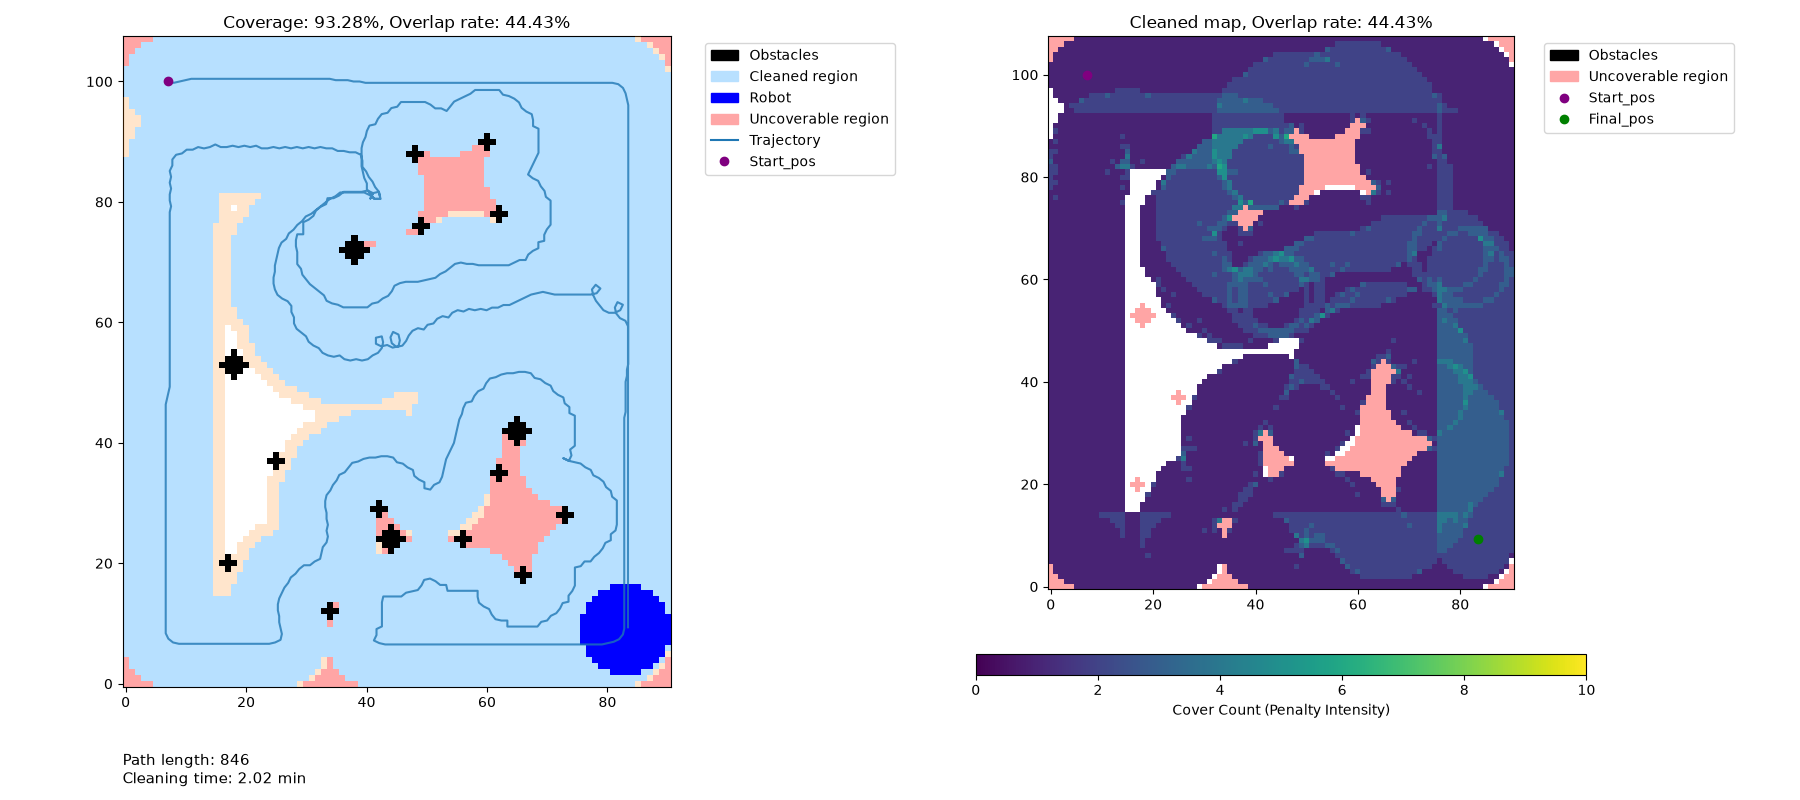


  [Worst Paths] (Top 3)
    #1 - Map name: test_map_L2_0105.npy | Final Cov: 19.3%, Overlap: 21.4%, Time: 0.8m


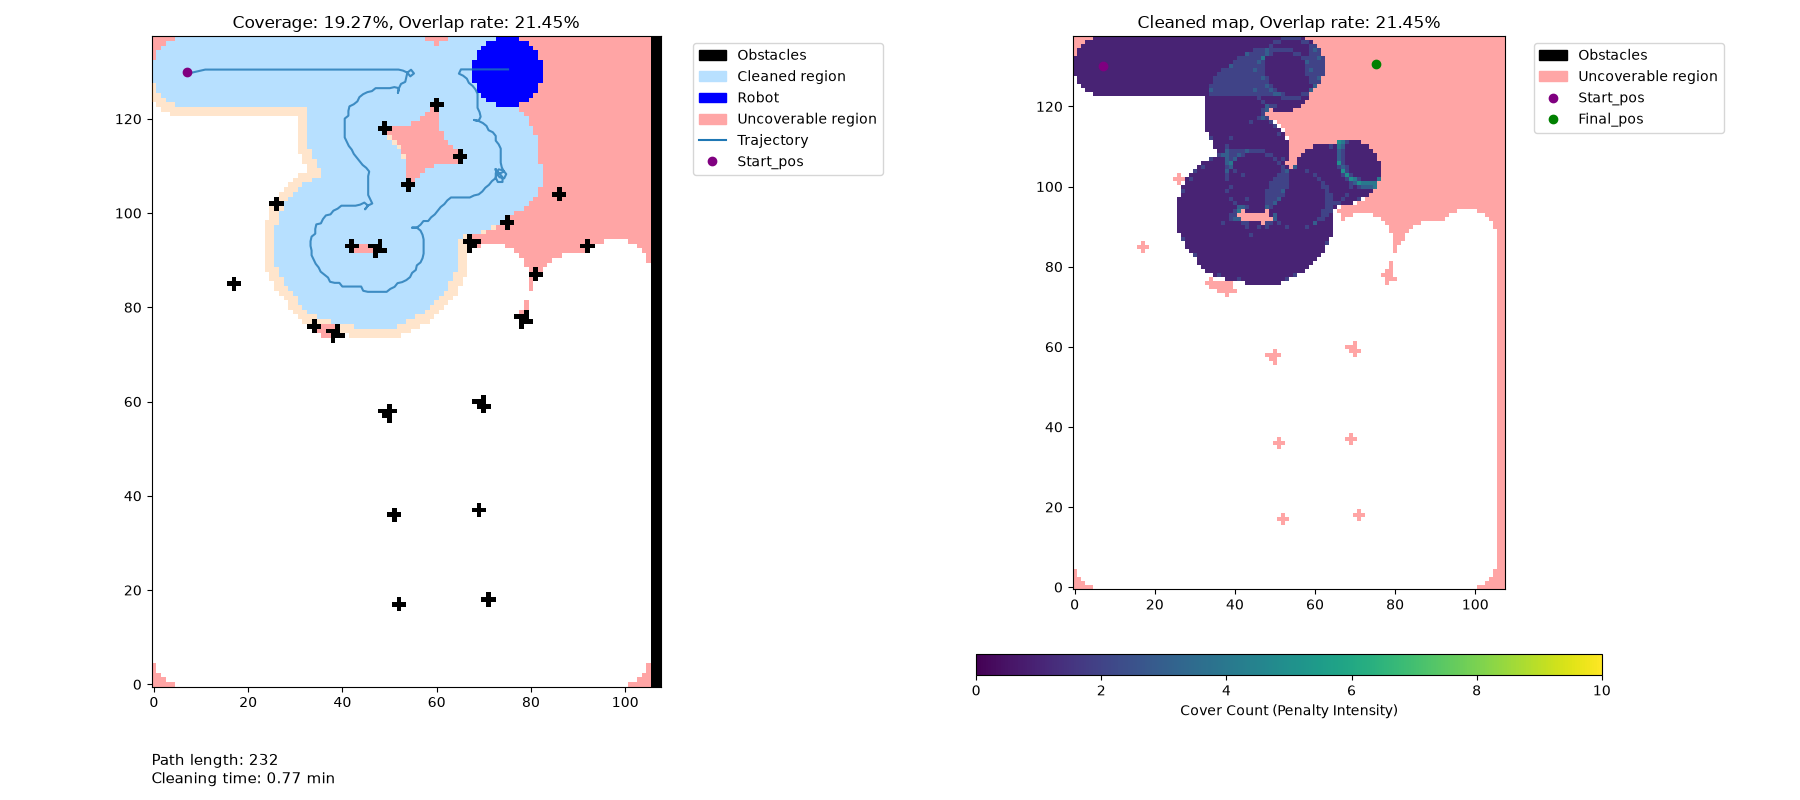

    #2 - Map name: test_map_L2_0099.npy | Final Cov: 22.4%, Overlap: 49.4%, Time: 0.8m


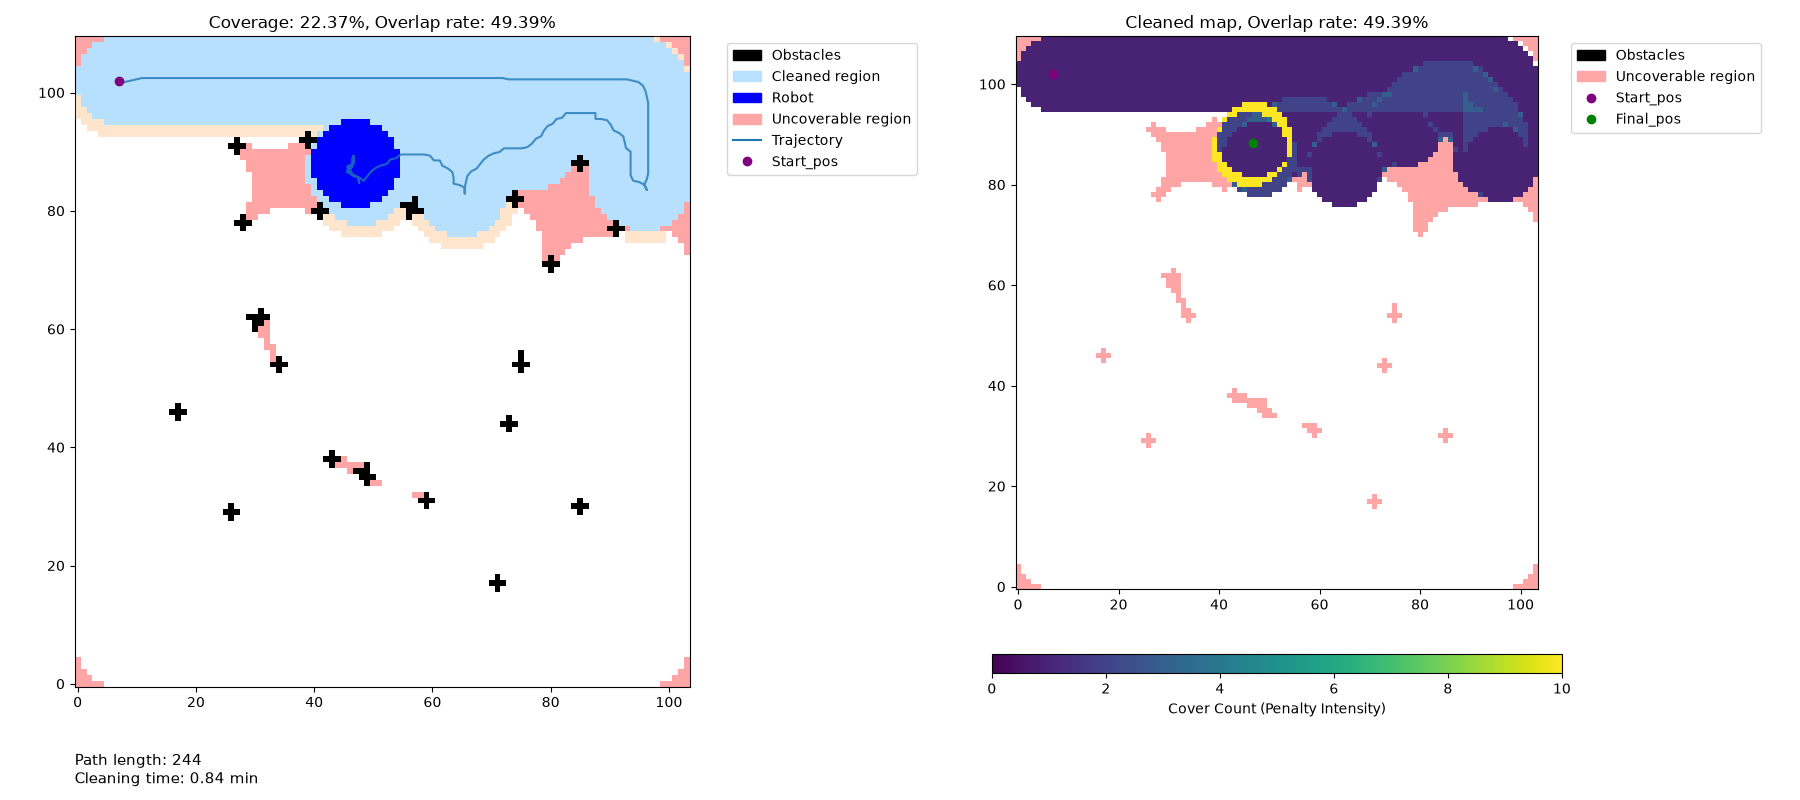

    #3 - Map name: test_map_L2_0067.npy | Final Cov: 41.9%, Overlap: 33.0%, Time: 1.0m


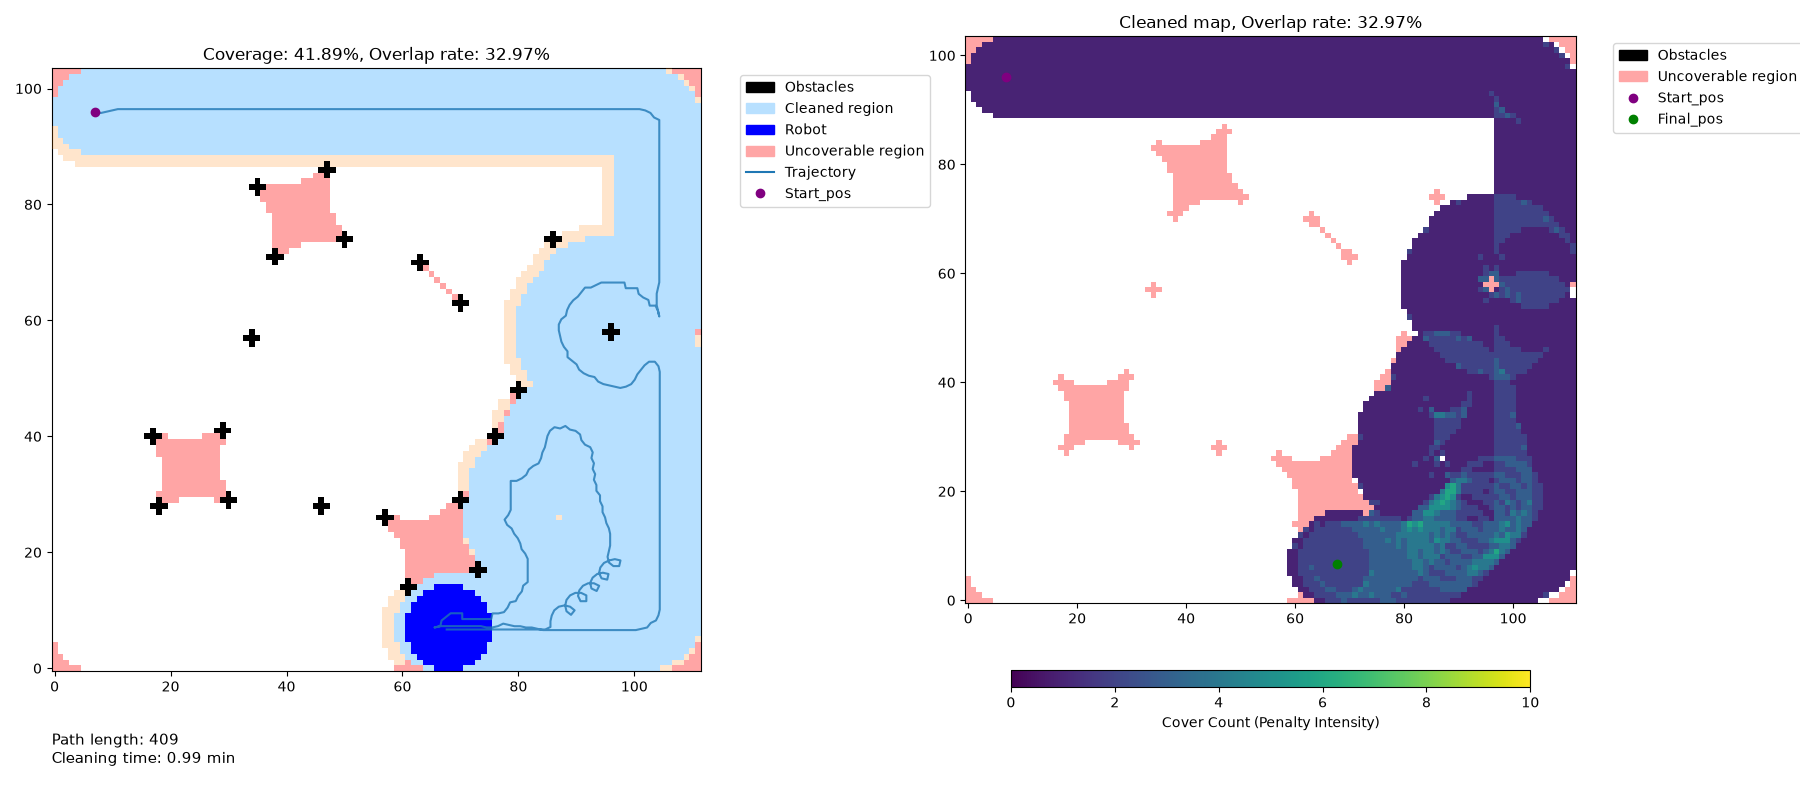


 Visualization for Map Condition Level 3

  [Best Paths] (Top 3)
    #1 - Map name: test_map_L3_0030.npy | Final Cov: 95.1%, Overlap: 30.5%, Time: 1.7m


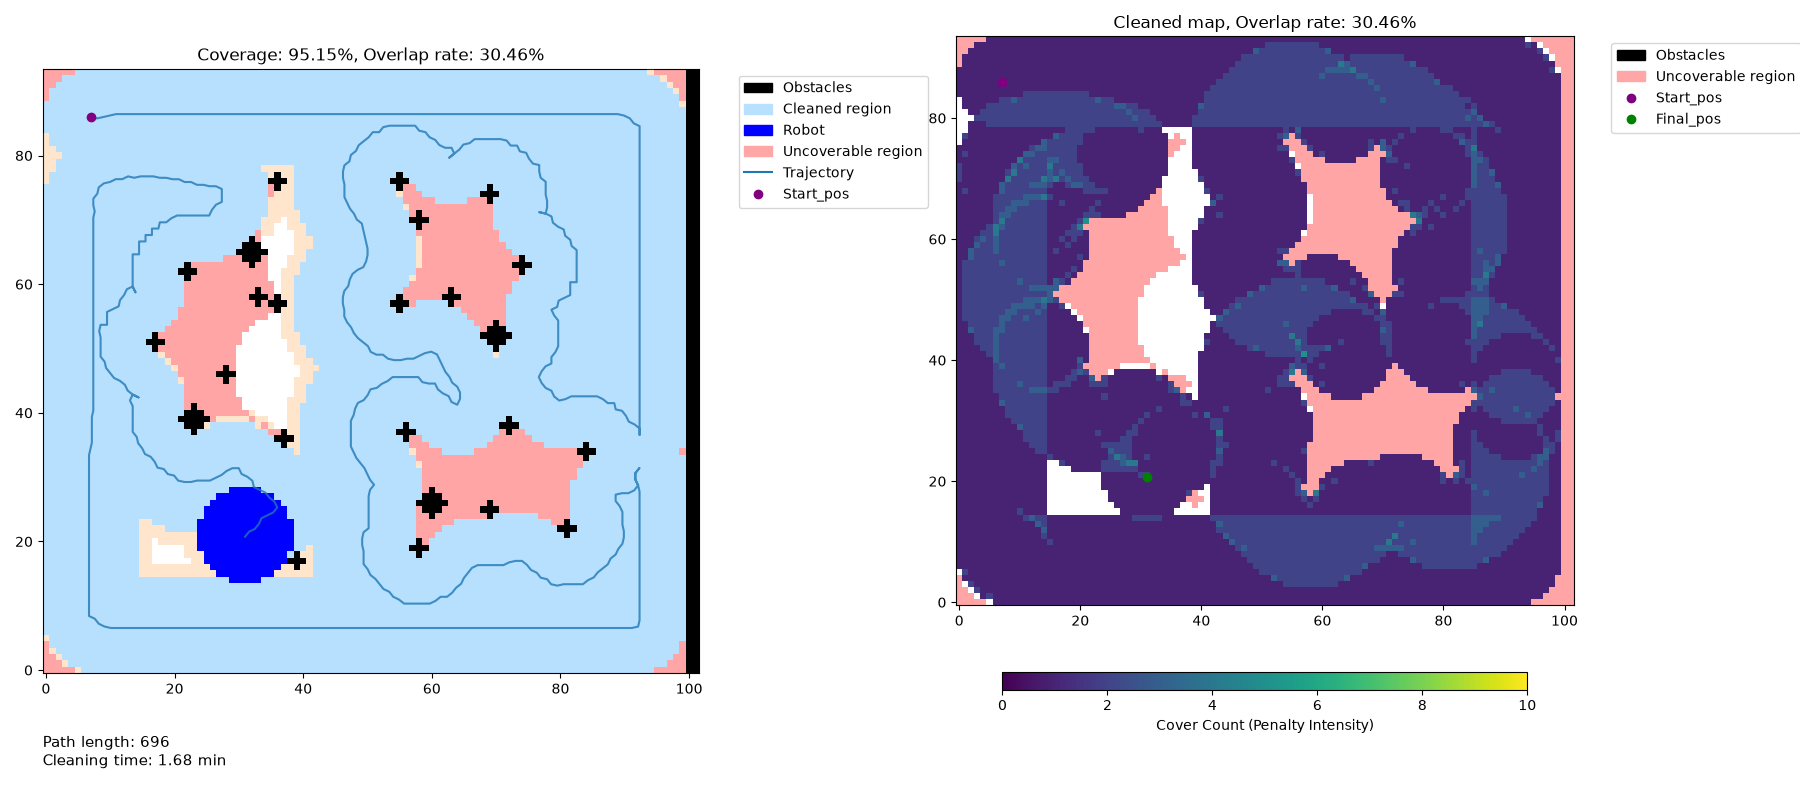

    #2 - Map name: test_map_L3_0160.npy | Final Cov: 95.1%, Overlap: 27.4%, Time: 1.8m


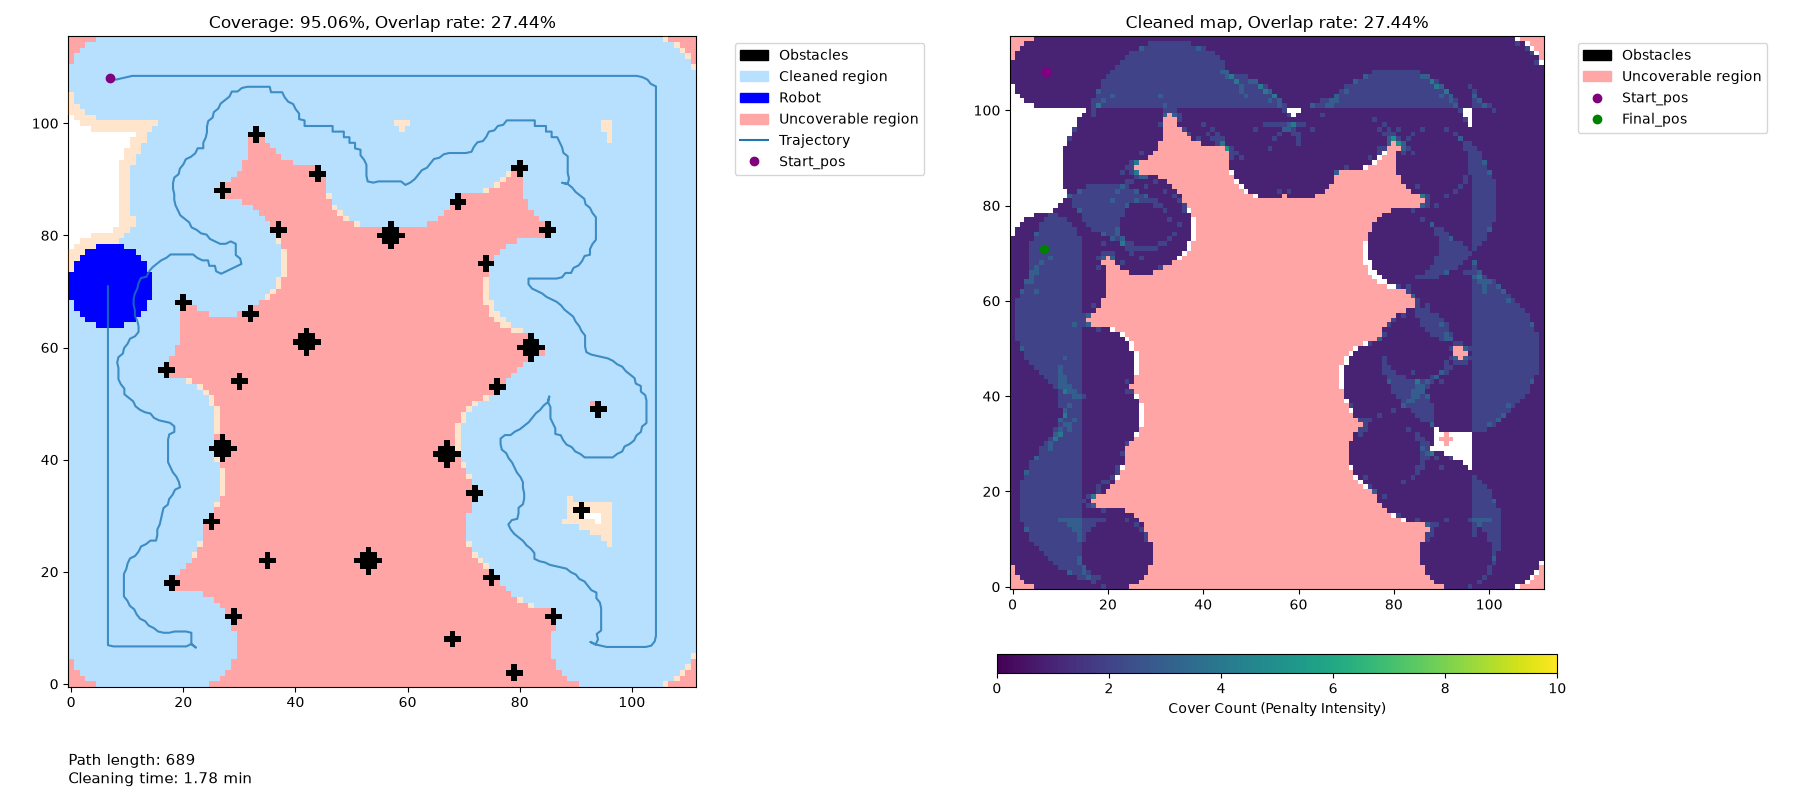

    #3 - Map name: test_map_L3_0151.npy | Final Cov: 95.0%, Overlap: 18.1%, Time: 2.1m


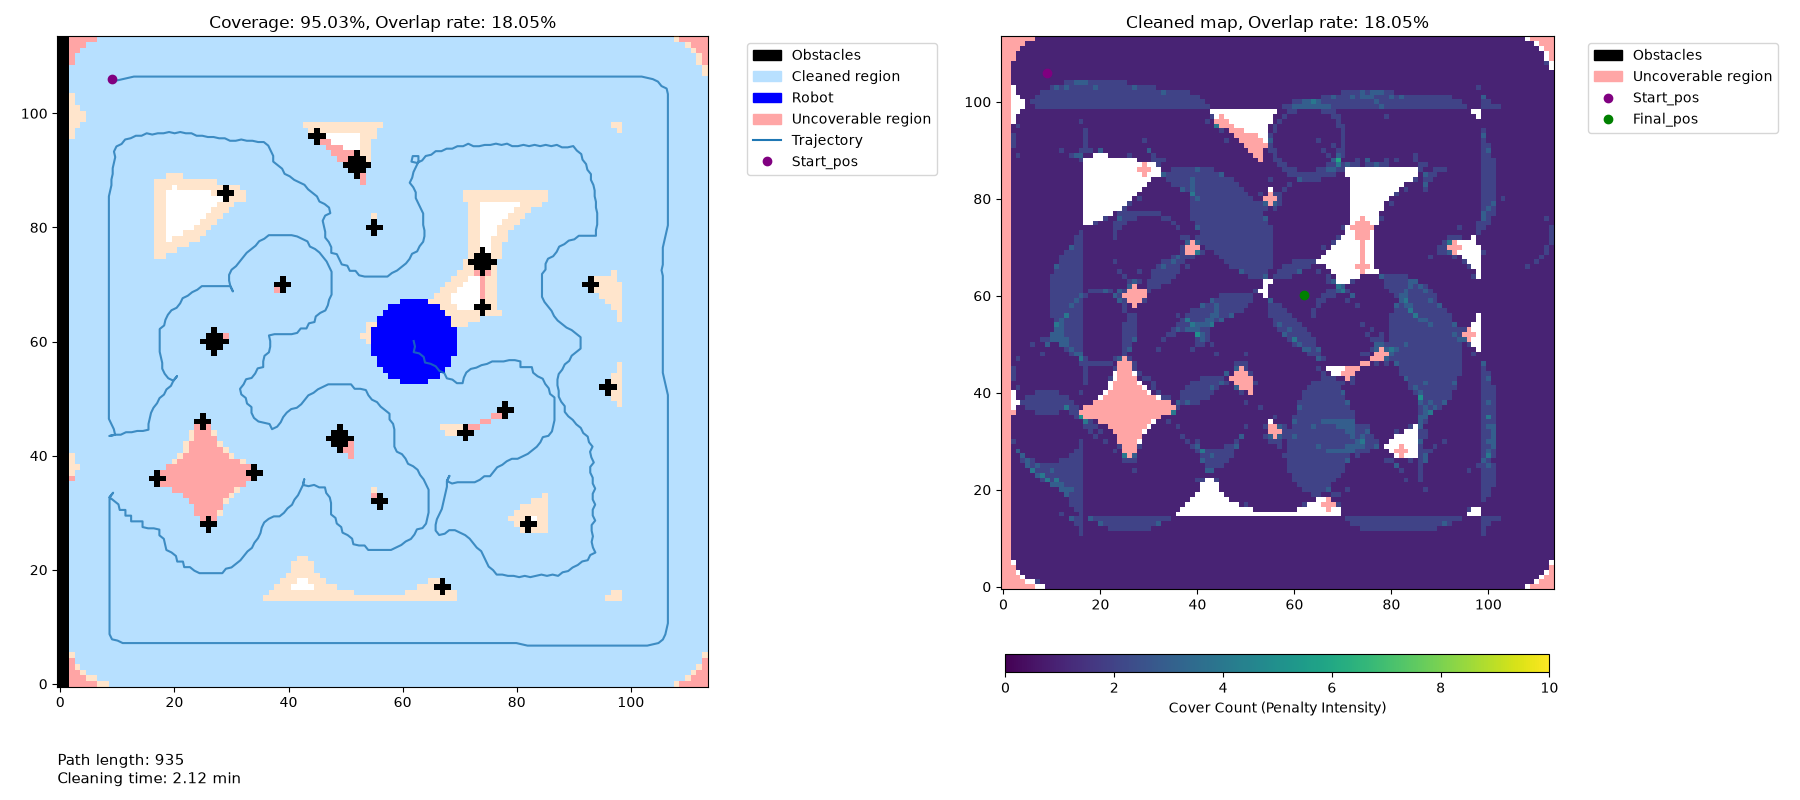


  [Median Paths] (Top 3)
    #1 - Map name: test_map_L3_0166.npy | Final Cov: 93.8%, Overlap: 43.1%, Time: 3.1m


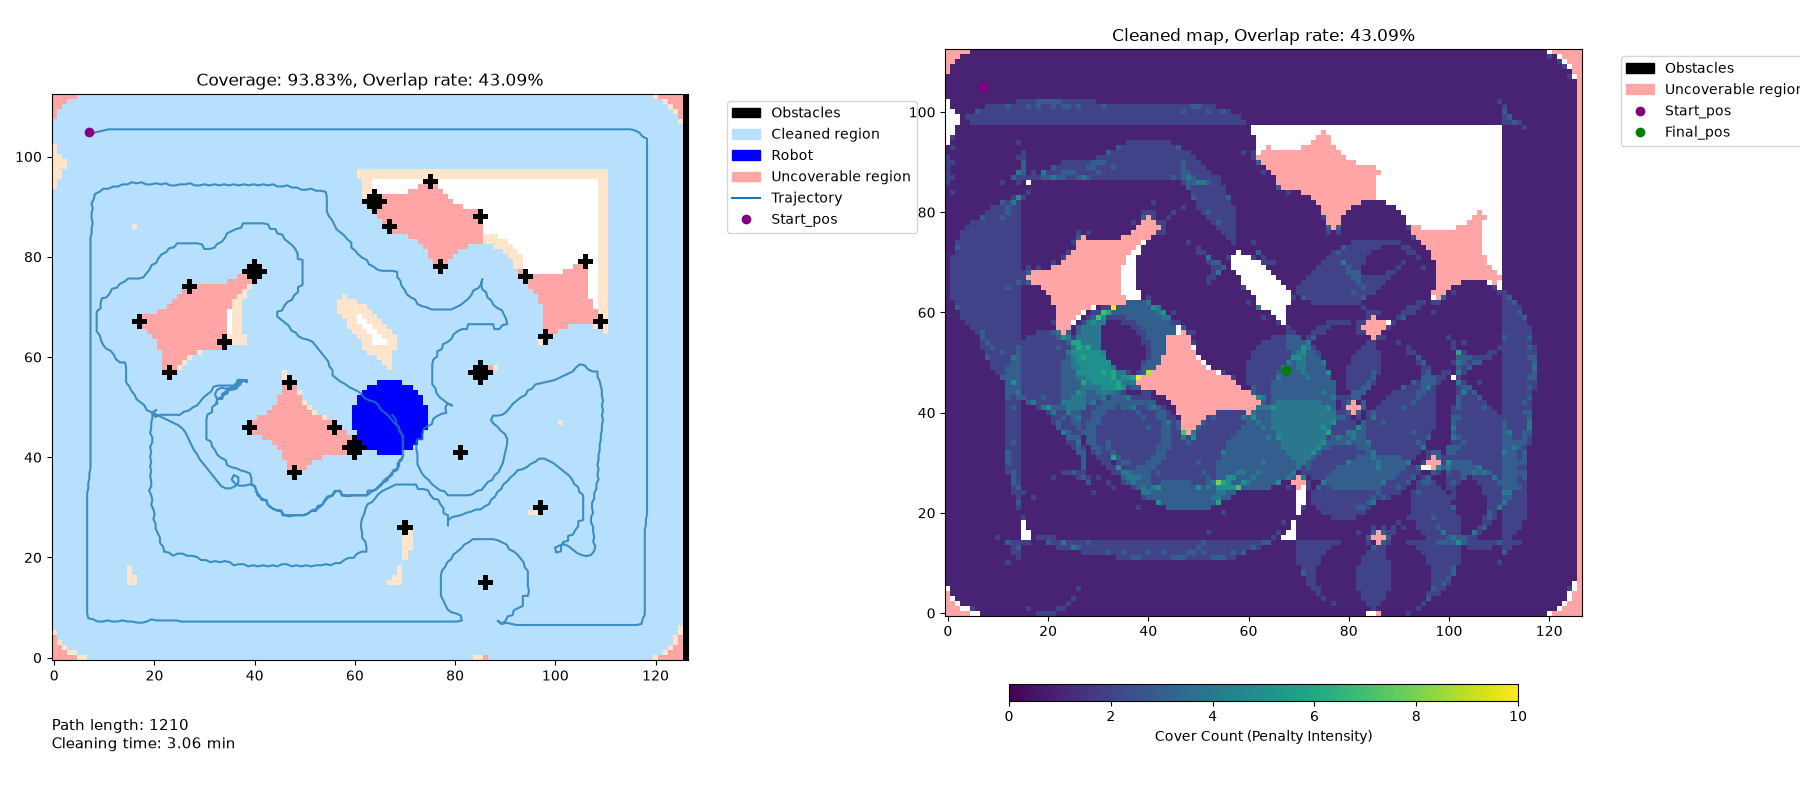

    #2 - Map name: test_map_L3_0210.npy | Final Cov: 94.8%, Overlap: 54.9%, Time: 3.0m


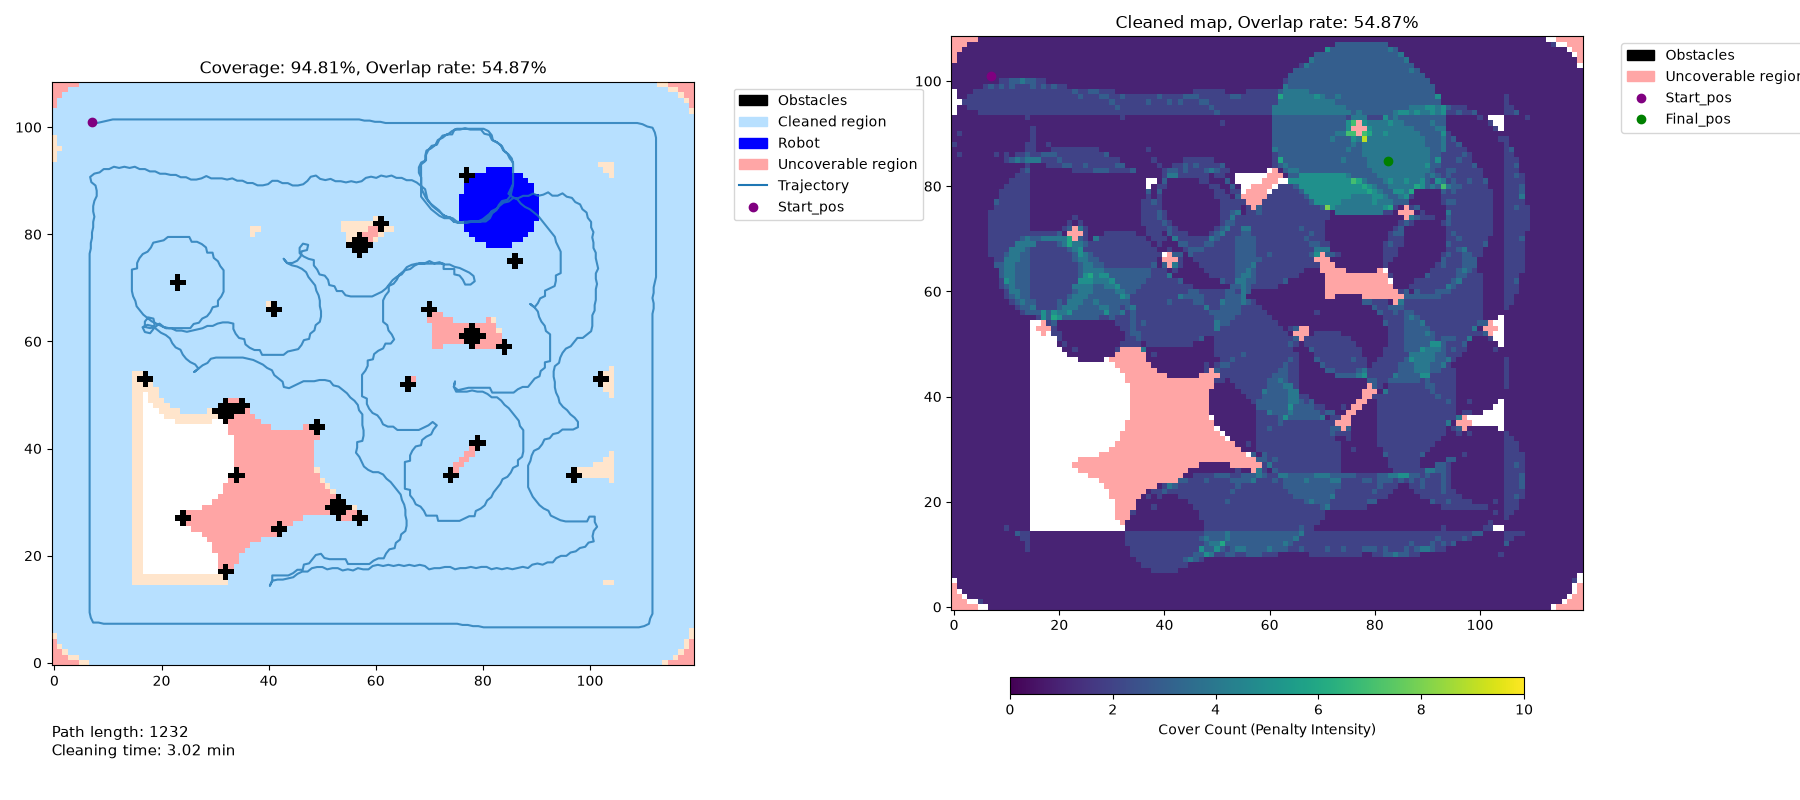

    #3 - Map name: test_map_L3_0194.npy | Final Cov: 91.8%, Overlap: 48.1%, Time: 3.1m


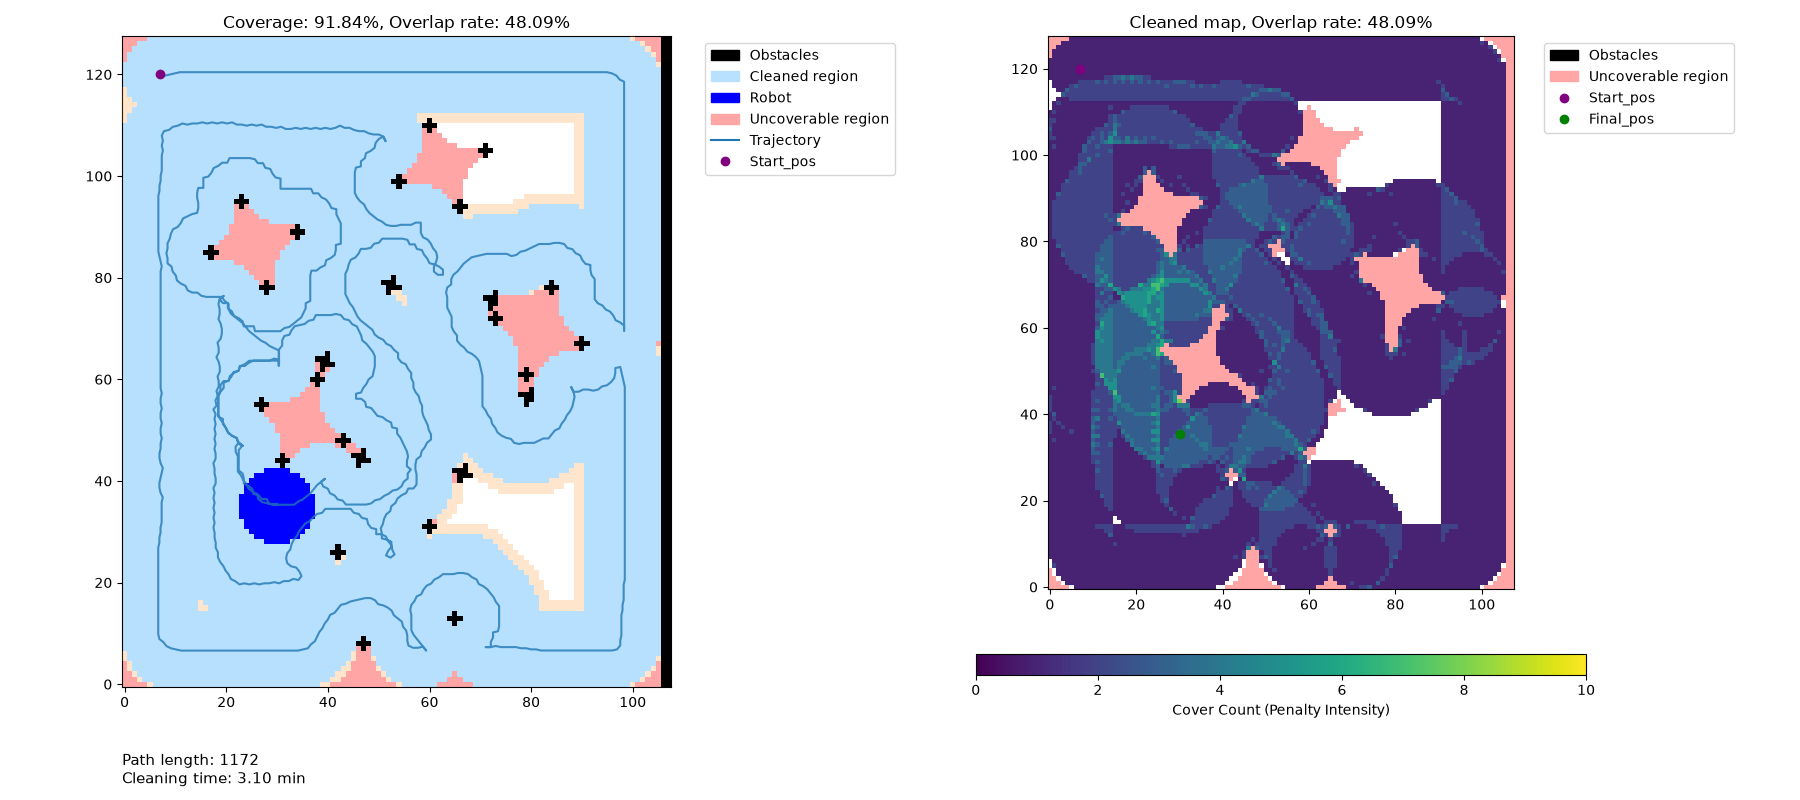


  [Worst Paths] (Top 3)
    #1 - Map name: test_map_L3_0114.npy | Final Cov: 40.1%, Overlap: 42.4%, Time: 1.5m


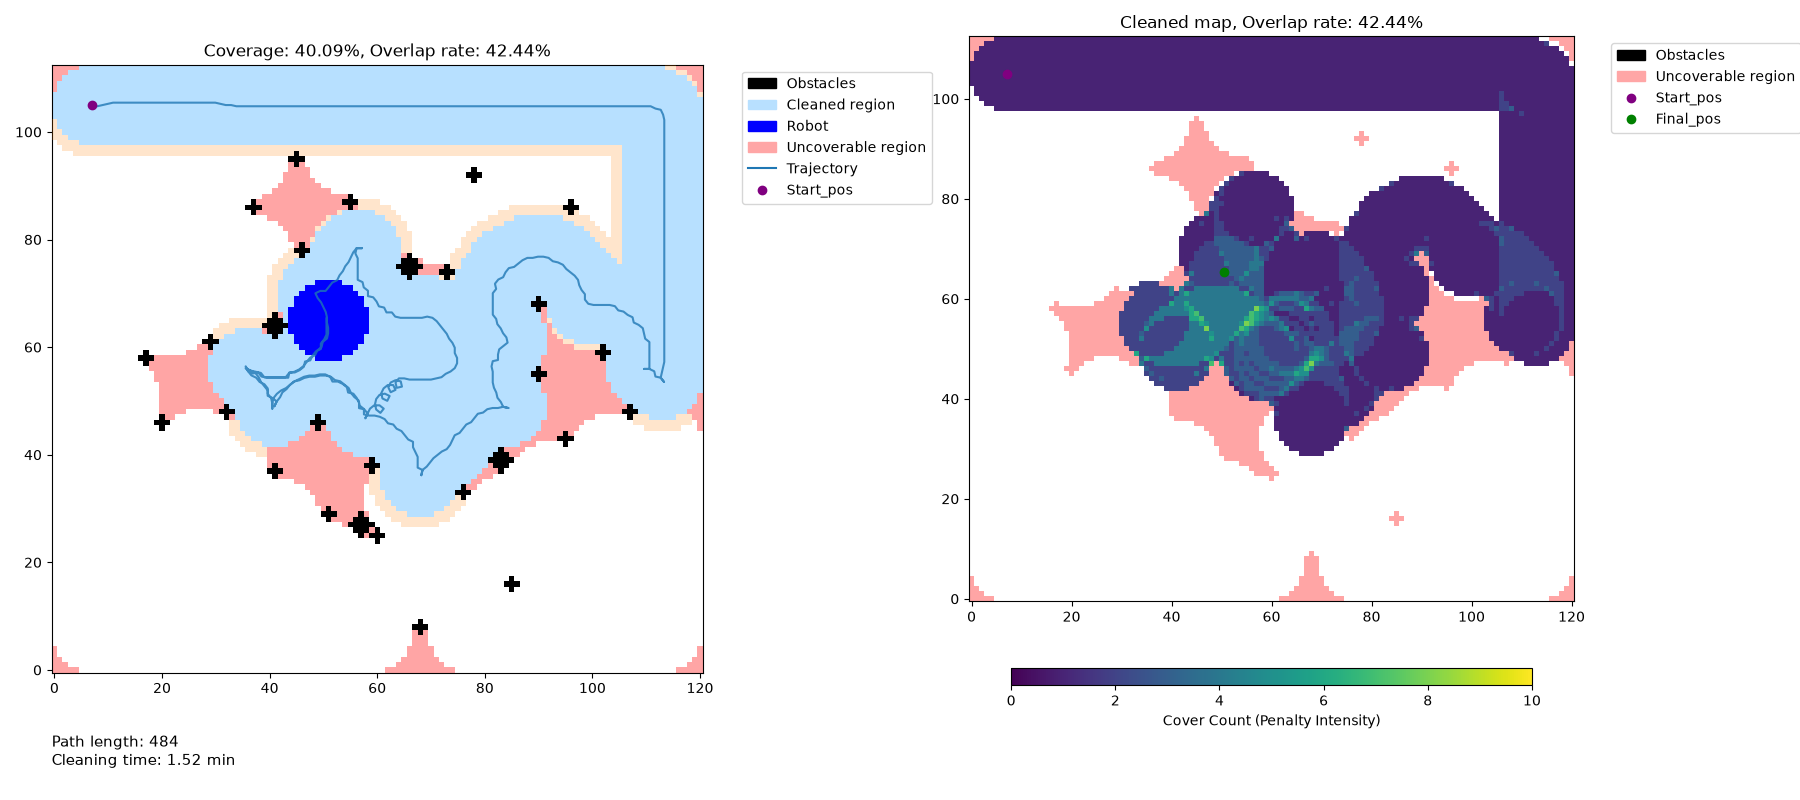

    #2 - Map name: test_map_L3_0225.npy | Final Cov: 48.0%, Overlap: 17.6%, Time: 1.8m


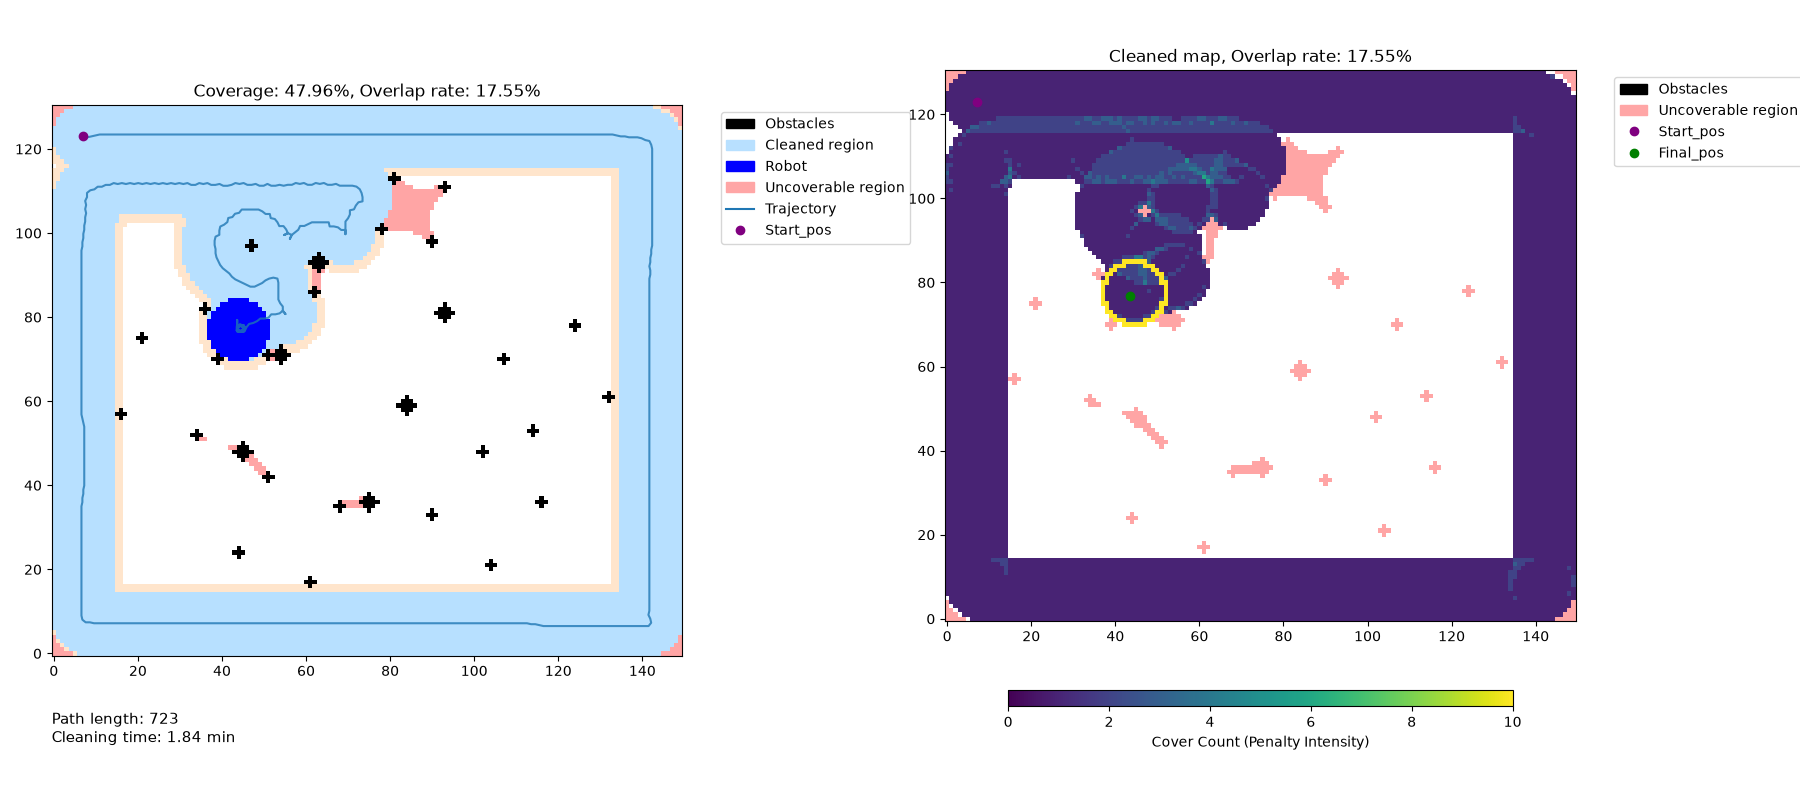

    #3 - Map name: test_map_L3_0060.npy | Final Cov: 48.4%, Overlap: 26.2%, Time: 1.4m


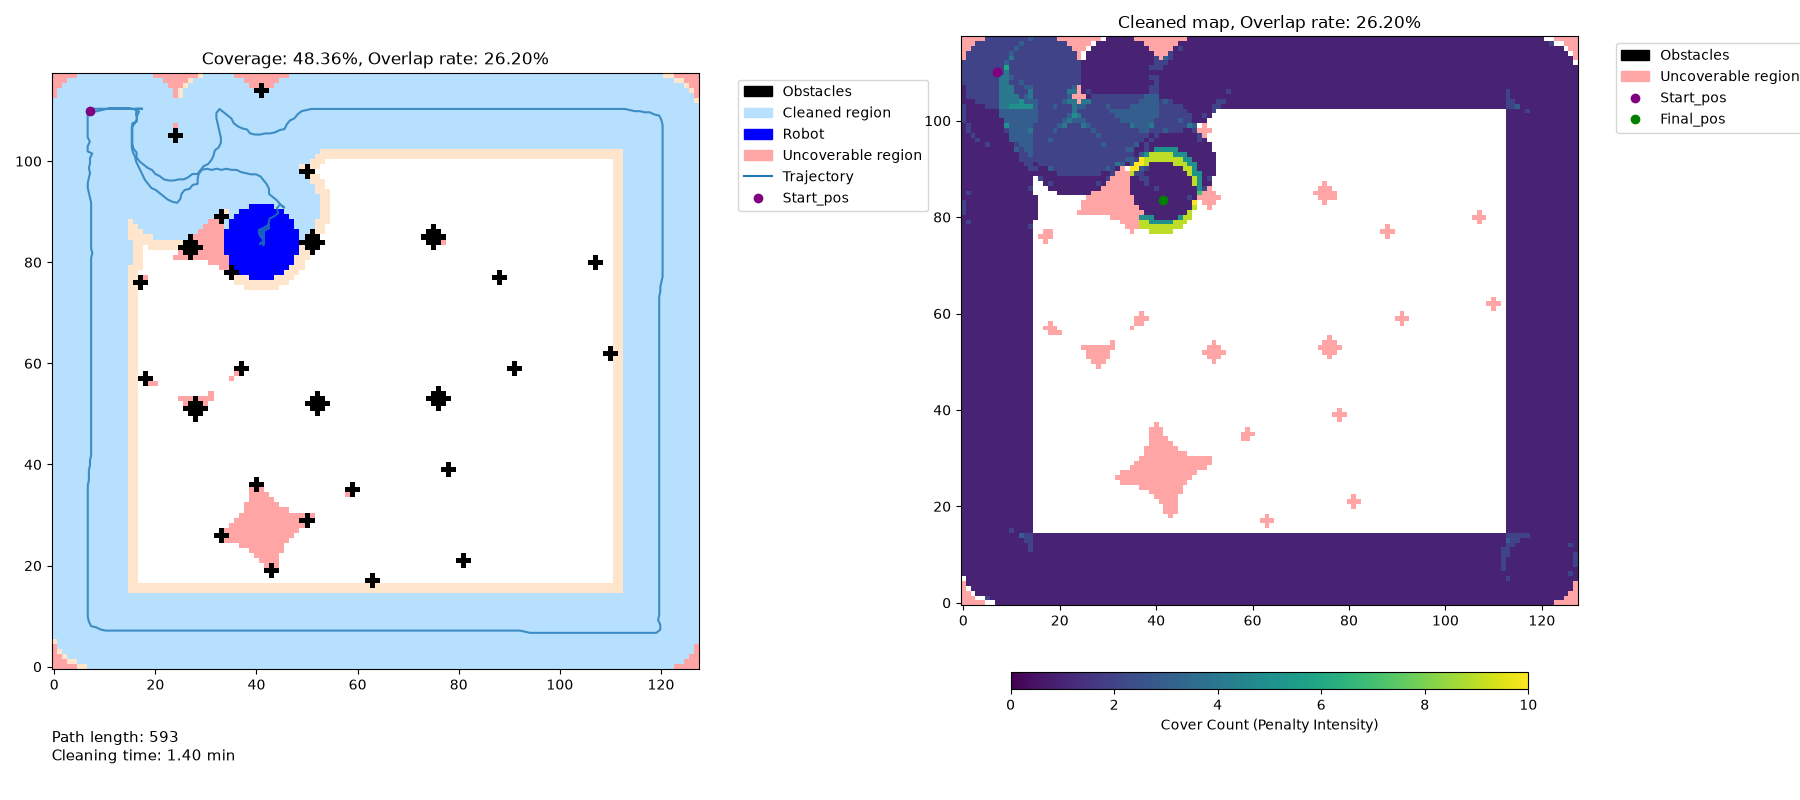


 Visualization for Map Condition Level 4

  [Best Paths] (Top 3)
    #1 - Map name: test_map_L4_0024.npy | Final Cov: 95.1%, Overlap: 17.5%, Time: 1.4m


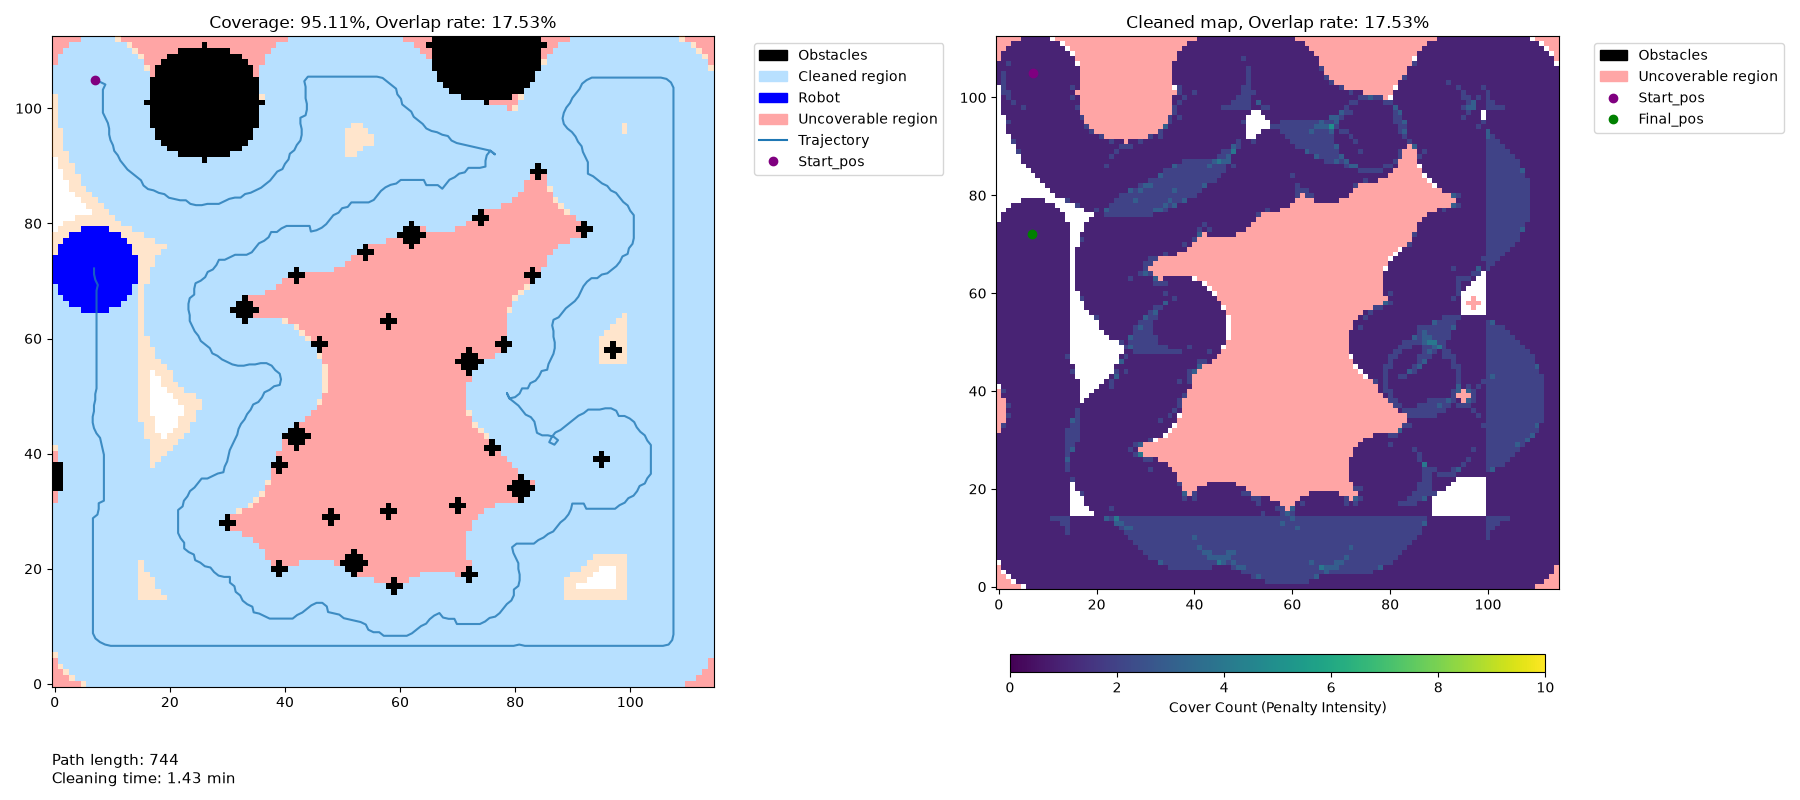

    #2 - Map name: test_map_L4_0137.npy | Final Cov: 95.0%, Overlap: 19.3%, Time: 1.9m


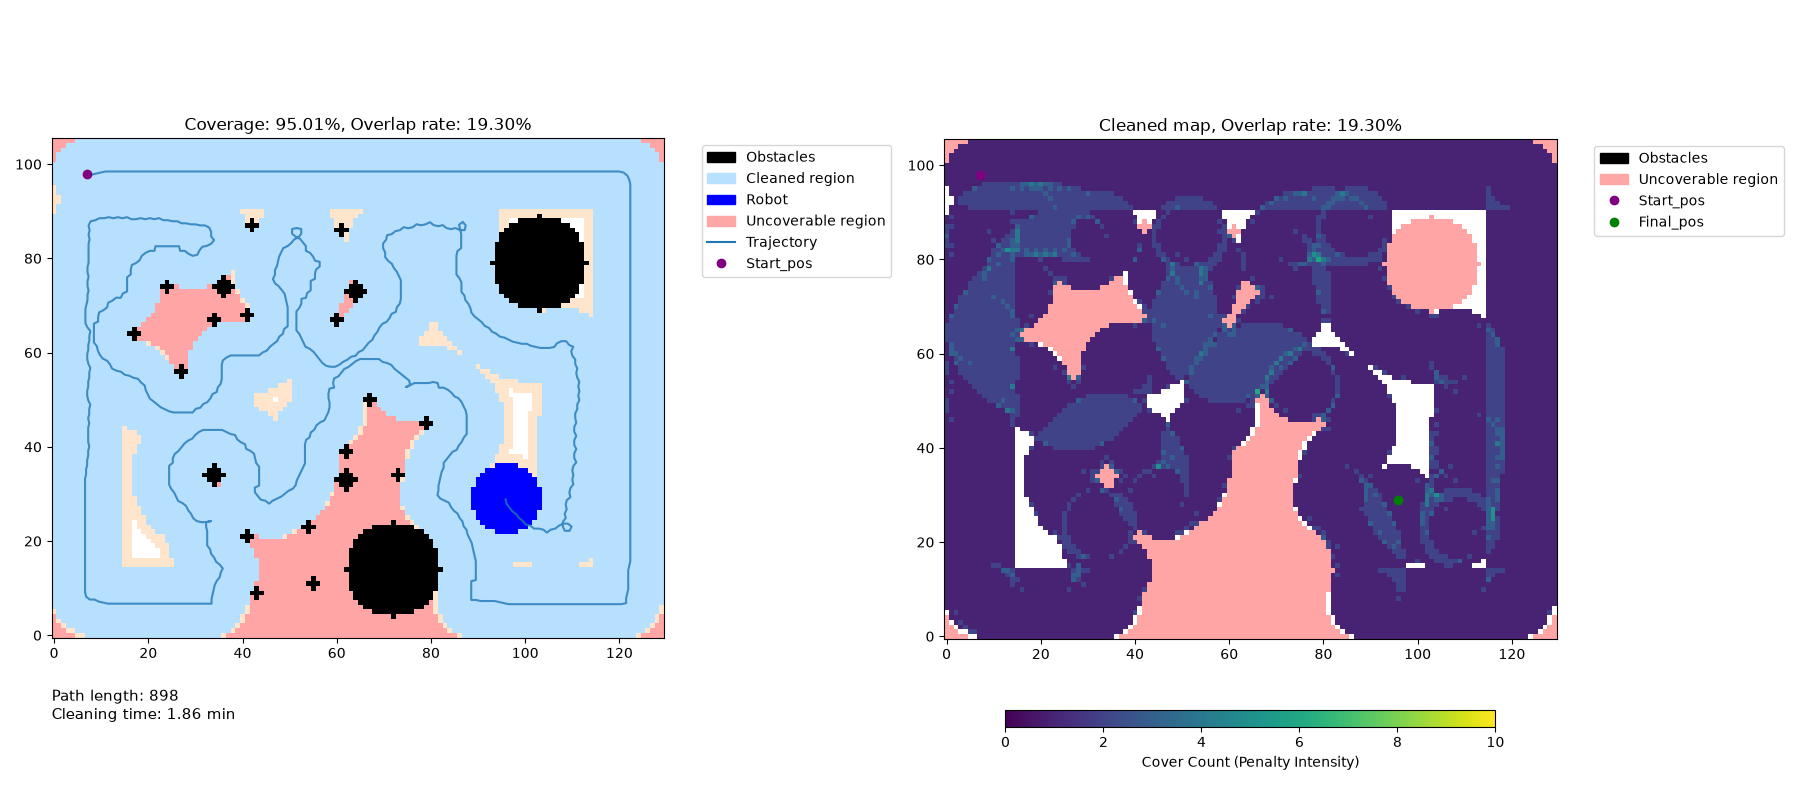

    #3 - Map name: test_map_L4_0179.npy | Final Cov: 95.0%, Overlap: 20.7%, Time: 1.9m


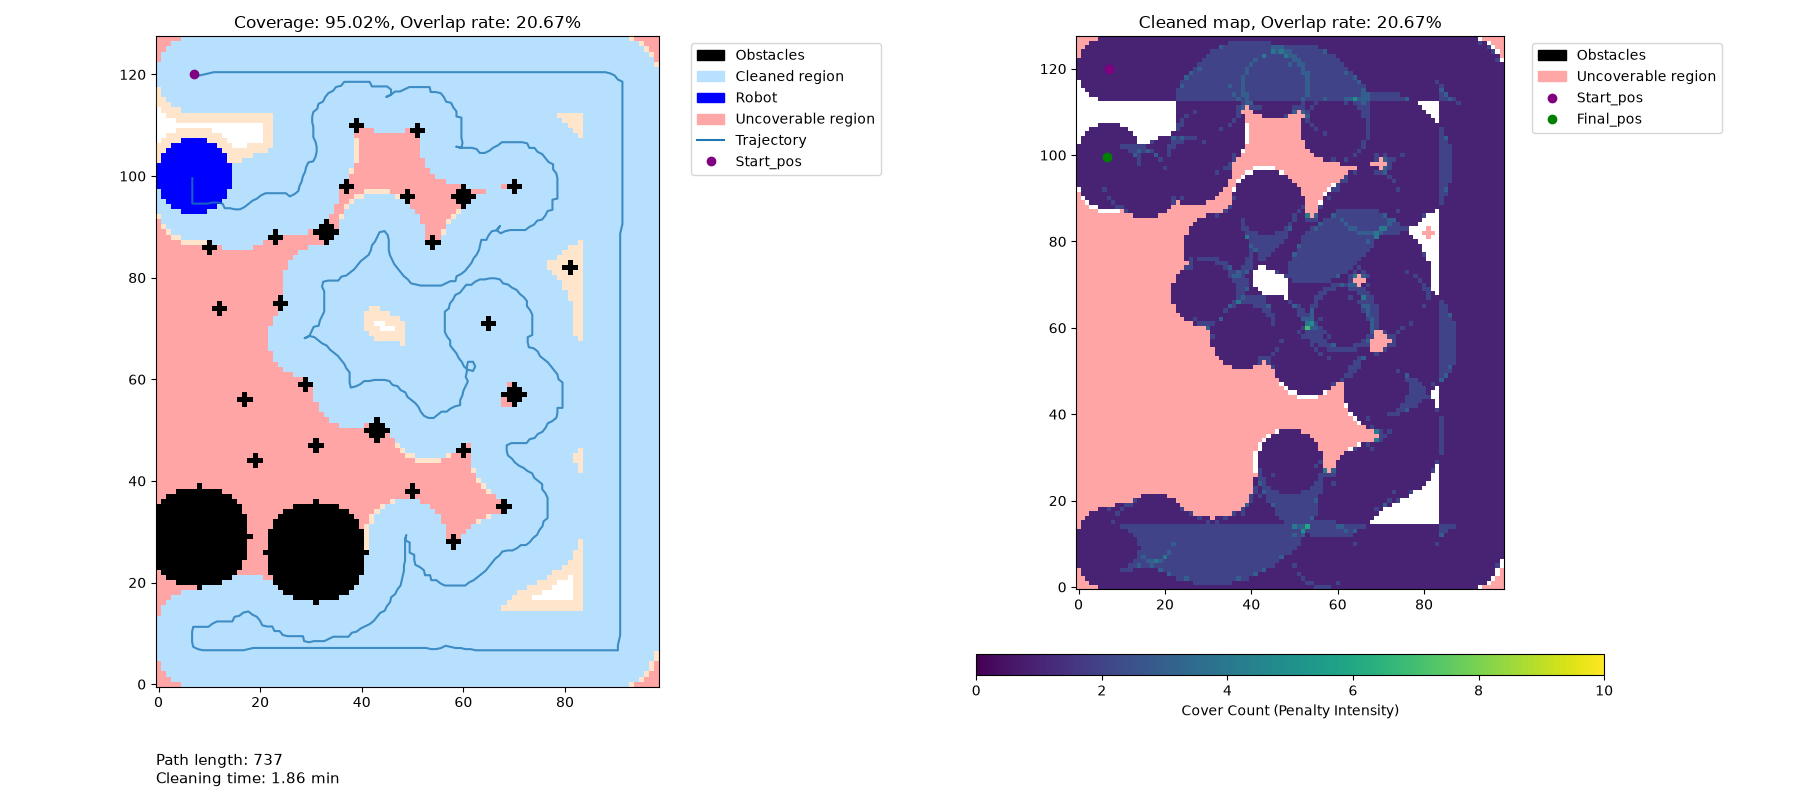


  [Median Paths] (Top 3)
    #1 - Map name: test_map_L4_0053.npy | Final Cov: 95.0%, Overlap: 49.6%, Time: 4.2m


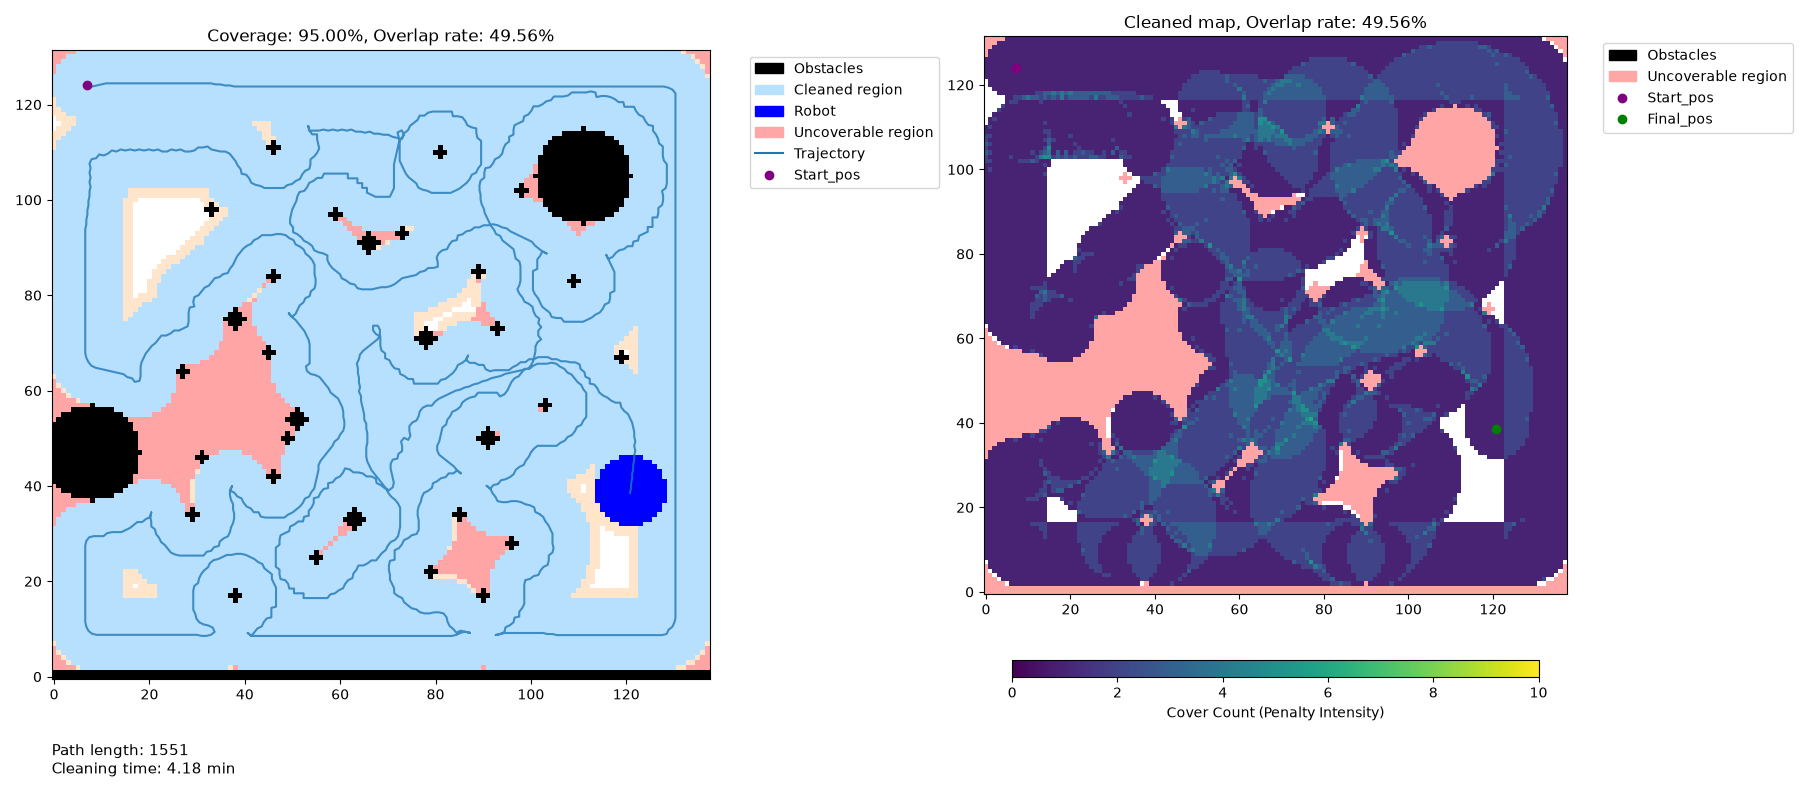

    #2 - Map name: test_map_L4_0165.npy | Final Cov: 95.1%, Overlap: 48.0%, Time: 4.2m


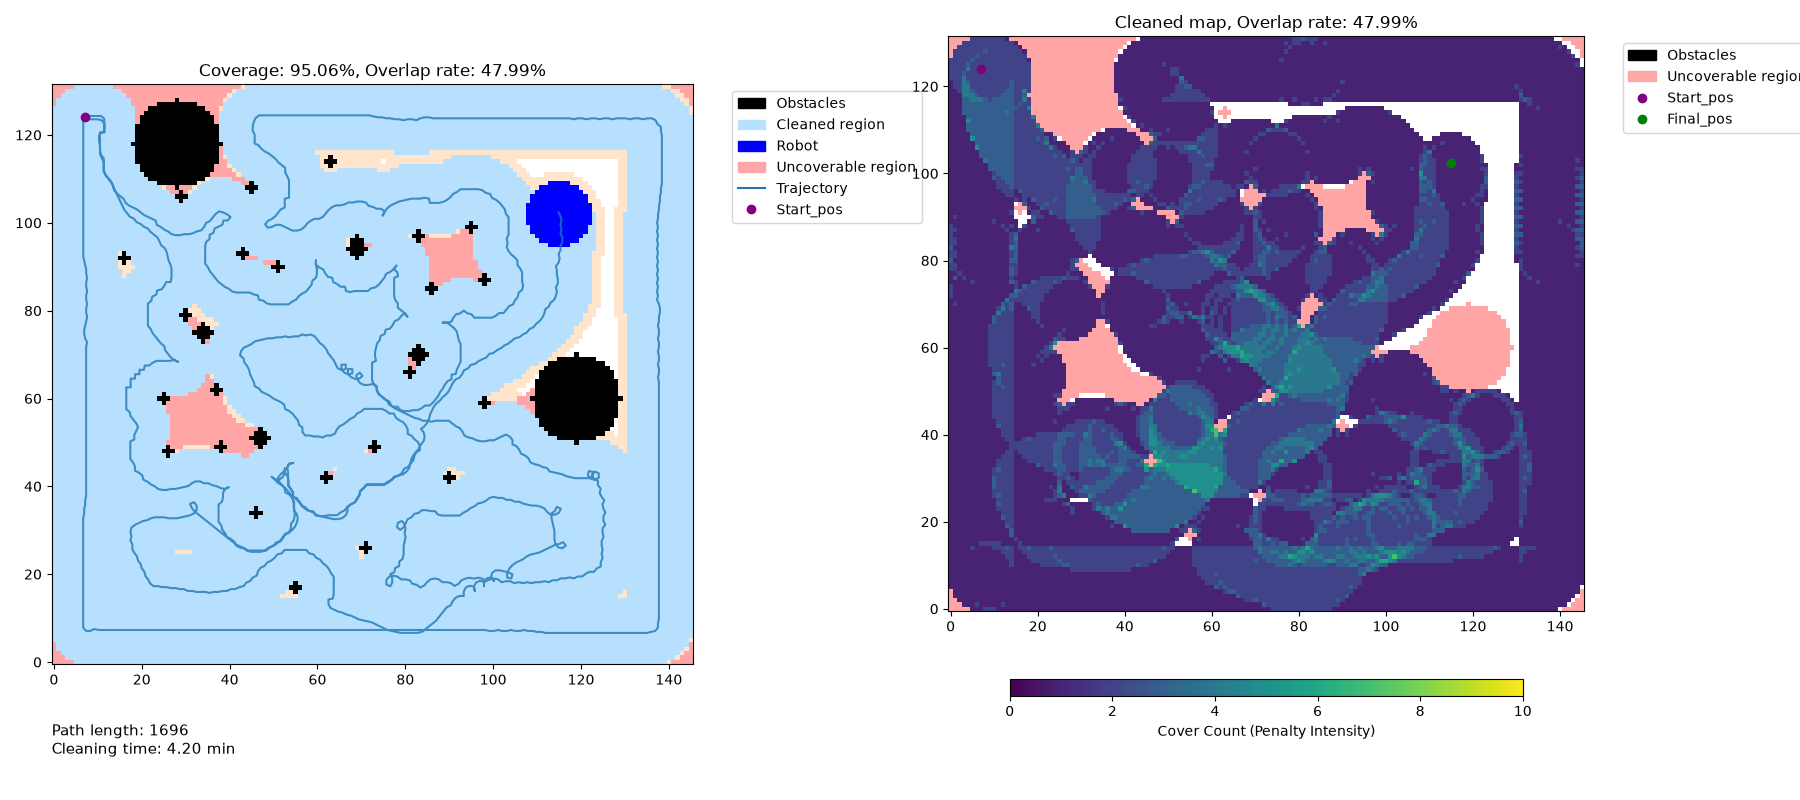

    #3 - Map name: test_map_L4_0096.npy | Final Cov: 95.0%, Overlap: 41.7%, Time: 4.2m


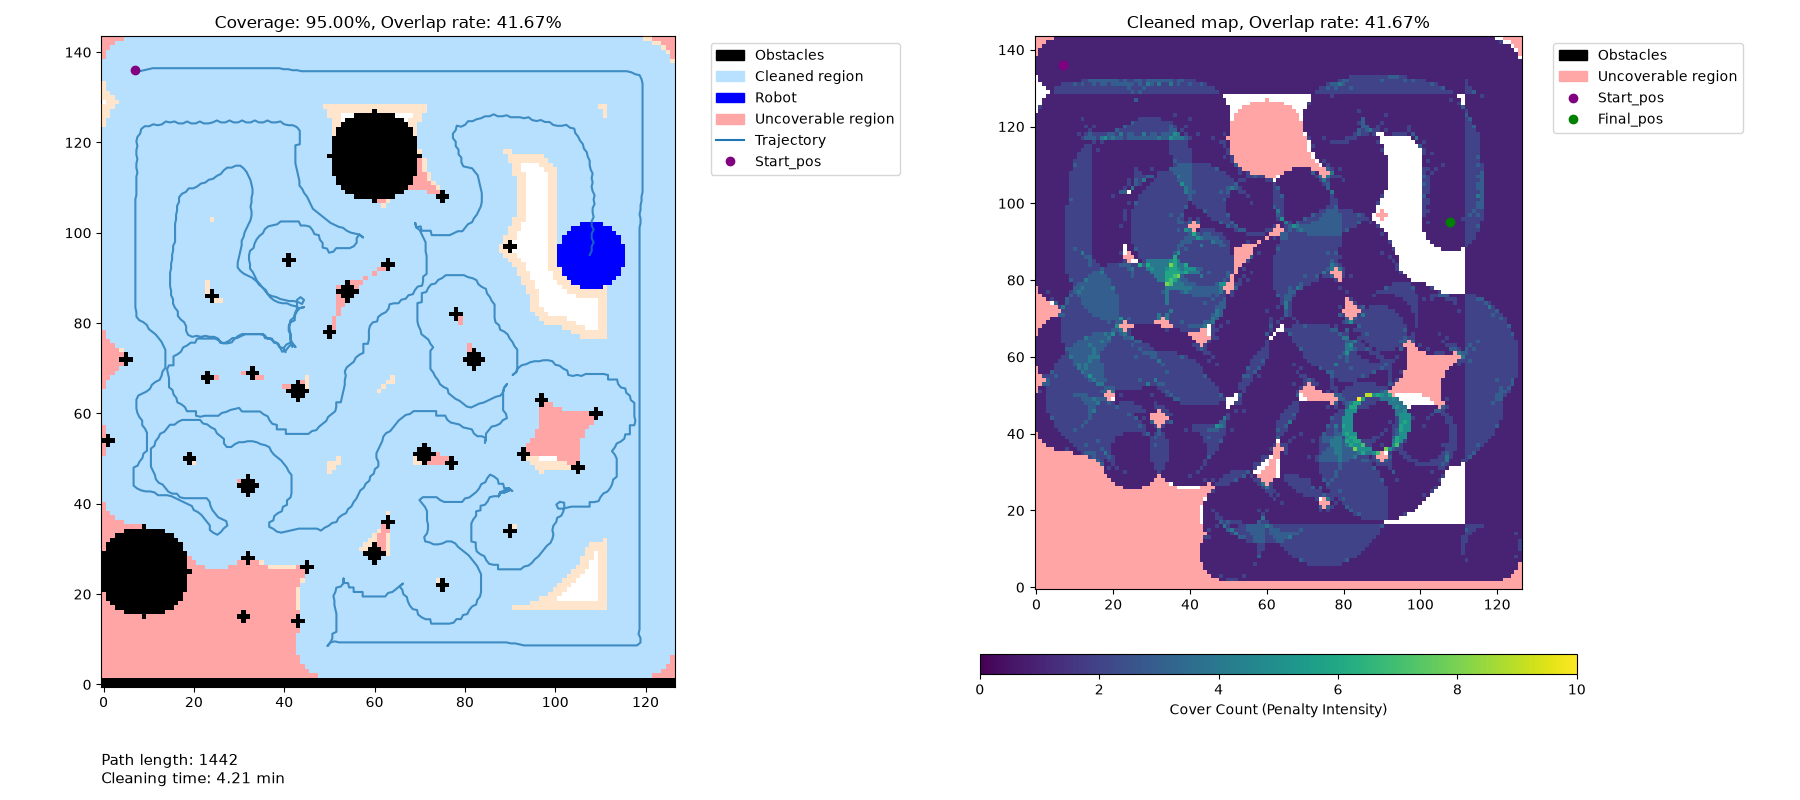


  [Worst Paths] (Top 3)
    #1 - Map name: test_map_L4_0134.npy | Final Cov: 12.5%, Overlap: 17.8%, Time: 0.5m


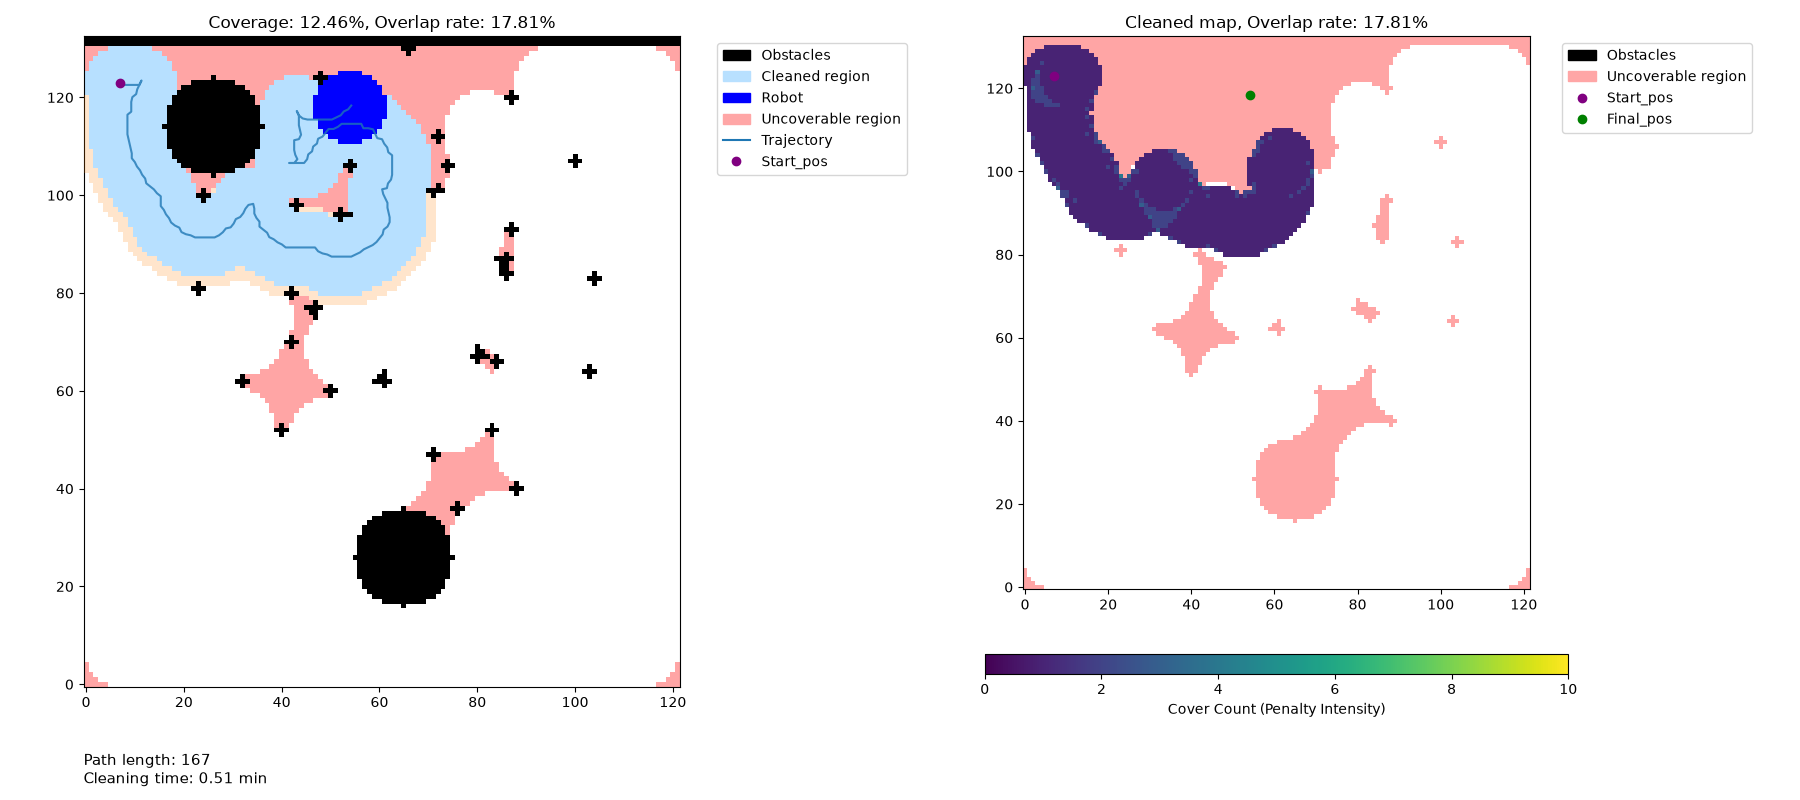

    #2 - Map name: test_map_L4_0132.npy | Final Cov: 22.6%, Overlap: 52.5%, Time: 1.9m


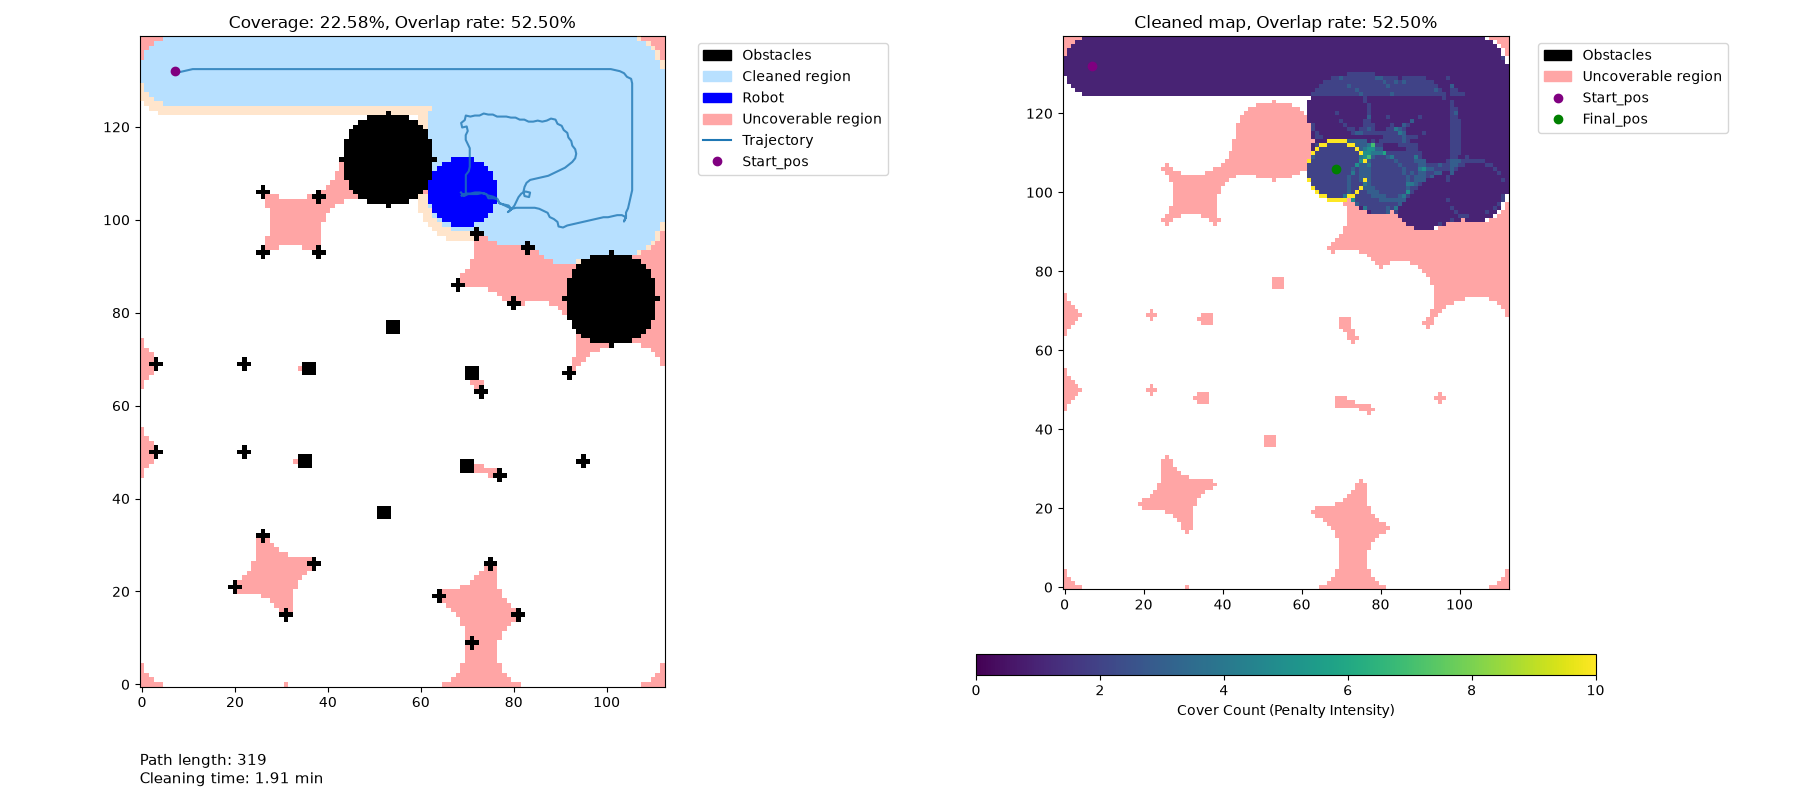

    #3 - Map name: test_map_L4_0225.npy | Final Cov: 23.0%, Overlap: 24.5%, Time: 0.9m


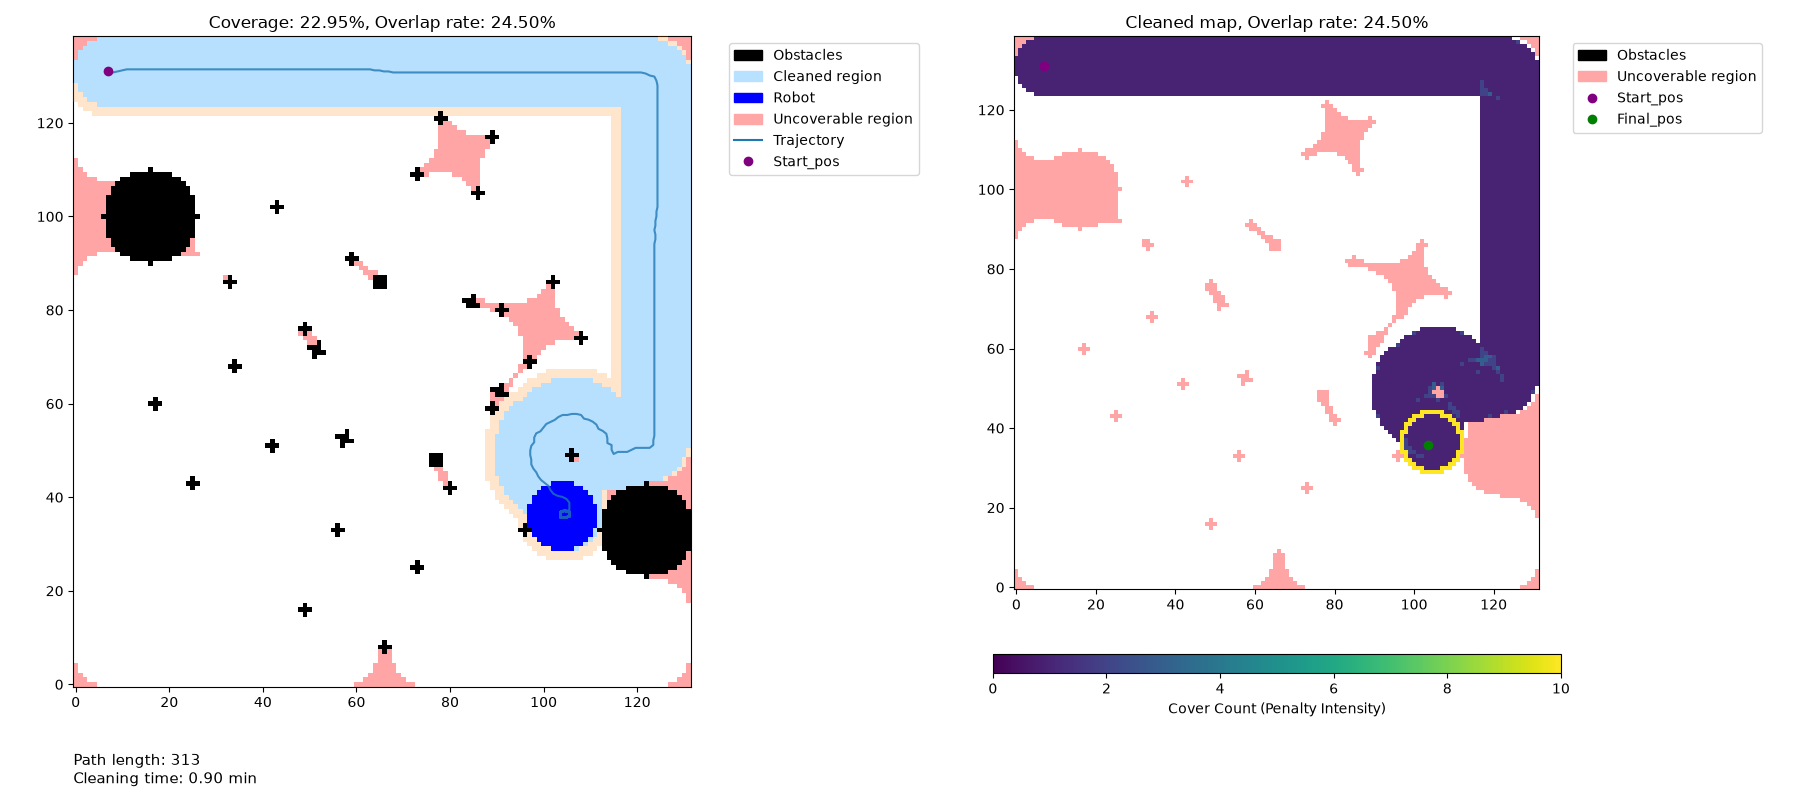

In [ ]:
%cd ~/LG_robot_DQN

from path_planner.main import main
import sys

args_str = """
    --mode test
    --model_name model.pth
    --test_map_num_per_level 250
    --vis_test_map_num 3
"""

sys.argv = [" "] + args_str.split()

# Training
main()